# Figure-1 Training Curve Plots — Weights & Biases export

Reads the per-seed CSVs saved in `results/training/` (from
`training_data_extraction_wandb.ipynb`) and produces journal-ready training
curves: mean +/- error across seeds.

Panels:

- **A.** Training loss (total = actor + critic)
- **B.** Training return (raw per-episode, not the rolling average)
- **C.** Training consumption
- **D.** Training L2 distance

More plotting cells can be added below this one.


## 1. Imports and data loading

Globs every `*_training.csv` in `results/training/` and parses the seed from the filename.

In [1]:
import re
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Canonical condition colour scheme (used across all experiments) ─────
C_NORMAL = "#1b4965"   # blue   — baseline / normal / no-clip
C_OVER   = "#c1121f"   # red    — over-eating
C_UNDER  = "#e07a00"   # orange — under-eating
C_TARGET = "green"     # target zone / target marker

# ── Central figure-save helper: one section folder per figure ───────────
PLOTS_ROOT   = Path("plots")
SAVE_FORMATS = ("png", "pdf", "svg", "eps")
def save_fig(fig, section, name, dpi=300):
    """Save `fig` as plots/<section>/<name>.{png,pdf,svg,eps}."""
    d = PLOTS_ROOT / section
    d.mkdir(parents=True, exist_ok=True)
    for ext in SAVE_FORMATS:
        fig.savefig(d / f"{name}.{ext}", dpi=dpi, bbox_inches="tight")
    print(f"saved {section}/{name}.[{'|'.join(SAVE_FORMATS)}]")

# ── Paths ───────────────────────────────────────────────────────────────
DATA_DIR = Path("results") / "training_data"
OUT_DIR  = Path("plots") / "plots_training"
OUT_DIR.mkdir(parents=True, exist_ok=True)

X_COL = "_step"   # episode counter logged by wandb


def load_seed_csvs(data_dir):
    """Load every Run_Seed*_training.csv into {seed: DataFrame}.

    Adds a derived 'train/total_loss' = actor_loss + critic_loss column.
    """
    files = sorted(glob(str(data_dir / "*_training.csv")))
    if not files:
        raise FileNotFoundError(
            f"No '*_training.csv' files in {data_dir}. "
            f"Run the extraction notebook first."
        )
    data = {}
    for f in files:
        m = re.search(r"Seed(\d+)", Path(f).name)
        seed = int(m.group(1)) if m else Path(f).stem
        df = pd.read_csv(f)
        if {"train/actor_loss", "train/critic_loss"}.issubset(df.columns):
            df["train/total_loss"] = df["train/actor_loss"] + df["train/critic_loss"]
        data[seed] = df
    print(f"Loaded {len(data)} seed(s): {sorted(data.keys())}")
    return data


def aggregate(data, metric, x_col=X_COL, err="sem"):
    """Align all seeds on x_col and return (x, mean, error) across seeds.

    err : 'sem' (standard error of the mean) or 'std' (standard deviation).
    """
    series = {}
    for seed, df in data.items():
        if metric not in df.columns:
            continue
        s = df[[x_col, metric]].dropna(subset=[x_col]).set_index(x_col)[metric]
        s = s[~s.index.duplicated(keep="last")]
        series[seed] = s
    if not series:
        raise KeyError(f"Metric '{metric}' not found in any seed CSV.")

    wide = pd.DataFrame(series).sort_index()   # index = step, columns = seeds
    mean = wide.mean(axis=1, skipna=True)
    std  = wide.std(axis=1, skipna=True, ddof=1)
    n    = wide.notna().sum(axis=1)
    error = std / np.sqrt(n) if err == "sem" else std
    error = error.fillna(0.0)                   # single seed -> zero band
    return wide.index.values, mean.values, error.values


data = load_seed_csvs(DATA_DIR)


Loaded 10 seed(s): [0, 7, 27, 42, 64, 100, 107, 1997, 2003, 2026]


## 2. Training curves (Panels A-D)

All font sizes and styling are controlled by the `rcParams` block at the top of
this cell.

**Y-axis zoom:** the first few episodes contain a large transient (loss/return
spike) that flattens the rest of the curve. `Y_CLIP=True` clips each panel's
y-limits to the `Y_CLIP_PERCENTILE` range of the mean±error, so the settled
dynamics and the error bands are visible. To show the full range including the
spike, set `Y_CLIP=False`, or override a single panel via `Y_LIMITS`.


saved fig1_training/fig1_training_curves.[png|pdf|svg|eps]


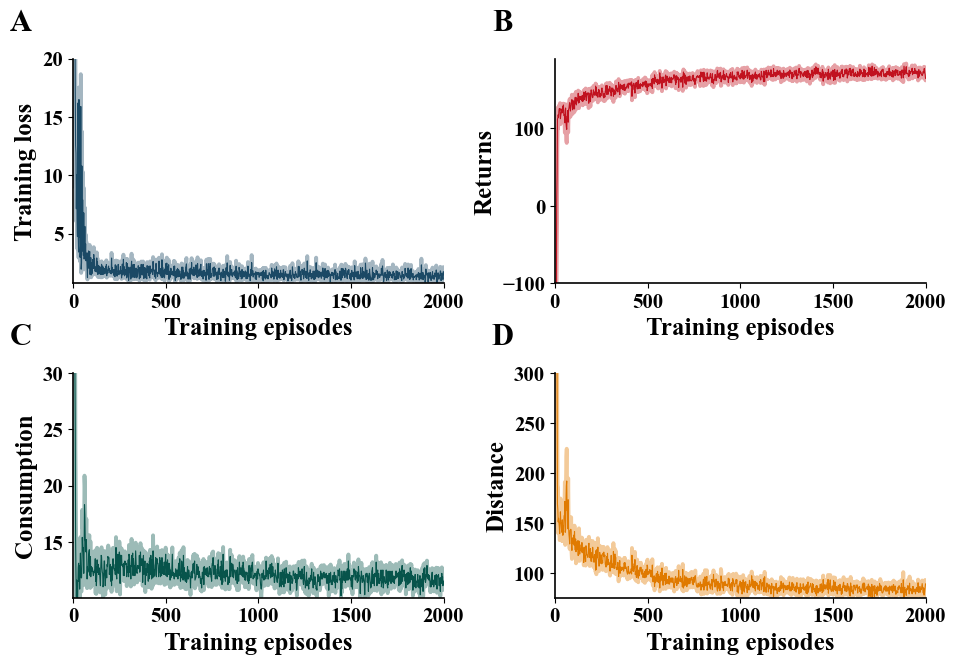

In [2]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE STYLE — all font sizes / styling controlled here
# ══════════════════════════════════════════════════════════════════════
#  FIGURE STYLE — all font sizes / styling controlled here
# ══════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "Nimbus Roman No9 L", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size":         16,
    "axes.titlesize":    18,
    "axes.labelsize":    18,
    "xtick.labelsize":   15,
    "ytick.labelsize":   15,
    "legend.fontsize":   15,
    "axes.linewidth":    1.2,
    "lines.linewidth":   2.2,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "svg.fonttype":      "none",
    # ── bold everything ──────────────────────────────
    "font.weight":       "bold",   # tick labels, legend, general text
    "axes.labelweight":  "bold",   # x / y axis labels
    "axes.titleweight":  "bold",   # subplot titles
    "mathtext.default":  "bf",     # bold math text (the ± in the legend)
})

PANEL_LABEL_SIZE = 22     # size of the A, B, C, D labels
BAND_LIGHTEN     = 0.60   # 0 = full colour band, 1 = white
ERROR            = "sem"  # 'sem' or 'std'

# ── colors: [loss, rewards, consumption, distance] ─────────────────────
COLORS = ["#1b4965", "#c1121f", "#07544b", "#e07a00"]
c_loss, c_rewards, c_consumption, c_distance = COLORS

import matplotlib.colors as mcolors
def lighten(color, amount):
    r, g, b = mcolors.to_rgb(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

fig, ((ax_loss, ax_rewards),
      (ax_consumption, ax_distance)) = plt.subplots(2, 2, figsize=(11, 7))
fig.subplots_adjust(wspace=0.3, hspace=0.4) 

# ── A: Total loss (actor + critic) ─────────────────────────────────────
x, mean, err = aggregate(data, "train/total_loss", err=ERROR)
ax_loss.fill_between(x, mean - err, mean + err, color=lighten(c_loss, BAND_LIGHTEN), linewidth=2.75)
ax_loss.plot(x, mean, color=c_loss, linewidth = 0.8)
ax_loss.set_xlabel("Training episodes")
ax_loss.set_ylabel("Training loss")
ax_loss.set_xlim(x.min() - 0.01 * (x.max() - x.min()), x.max())
# ax_loss.set_ylim(np.nanpercentile(mean - err, 1) * 0.9, np.nanpercentile(mean + err, 99) * 1.1)
ax_loss.set_ylim(np.nanpercentile(mean - err, 1) * 0.9, 20)
ax_loss.spines[["top", "right"]].set_visible(False)
ax_loss.text(-0.17, 1.22, "A", transform=ax_loss.transAxes,
             fontsize=PANEL_LABEL_SIZE, fontweight="bold", va="top", ha="left")

# ── B: Return ──────────────────────────────────────────────────────────
x, mean, err = aggregate(data, "train/reward", err=ERROR)
ax_rewards.fill_between(x, mean - err, mean + err, color=lighten(c_rewards, BAND_LIGHTEN), linewidth=2.75)
ax_rewards.plot(x, mean, color=c_rewards, linewidth =0.8)
ax_rewards.set_xlabel("Training episodes")
ax_rewards.set_ylabel("Returns")
ax_rewards.set_xlim(x.min() - 0.01 * (x.max() - x.min()), x.max())
# ax_rewards.set_ylim(np.nanpercentile(mean - err, 1), np.nanpercentile(mean + err, 99) * 1.05)
ax_rewards.set_ylim(-100, np.nanpercentile(mean + err, 99) * 1.05)
ax_rewards.spines[["top", "right"]].set_visible(False)
ax_rewards.text(-0.17, 1.22, "B", transform=ax_rewards.transAxes,
                fontsize=PANEL_LABEL_SIZE, fontweight="bold", va="top", ha="left")

# ── C: Consumption ─────────────────────────────────────────────────────
x, mean, err = aggregate(data, "train/consumption", err=ERROR)
ax_consumption.fill_between(x, mean - err, mean + err, color=lighten(c_consumption, BAND_LIGHTEN), linewidth=2.75)
ax_consumption.plot(x, mean, color=c_consumption, linewidth = 0.8)
ax_consumption.set_xlabel("Training episodes")
ax_consumption.set_ylabel("Consumption")
ax_consumption.set_xlim(x.min() - 0.01 * (x.max() - x.min()), x.max())
# ax_consumption.set_ylim(np.nanpercentile(mean - err, 1), np.nanpercentile(mean + err, 99))
ax_consumption.set_ylim(np.nanpercentile(mean - err, 1),30)
ax_consumption.spines[["top", "right"]].set_visible(False)
ax_consumption.text(-0.17, 1.22, "C", transform=ax_consumption.transAxes,
                    fontsize=PANEL_LABEL_SIZE, fontweight="bold", va="top", ha="left")

# ── D: L2 distance ─────────────────────────────────────────────────────
x, mean, err = aggregate(data, "train/distance", err=ERROR)
ax_distance.fill_between(x, mean - err, mean + err, color=lighten(c_distance, BAND_LIGHTEN), linewidth=2.75)
ax_distance.plot(x, mean, color=c_distance, linewidth = 0.8)
ax_distance.set_xlabel("Training episodes")
ax_distance.set_ylabel("Distance")
ax_distance.set_xlim(x.min() - 0.01 * (x.max() - x.min()), x.max())
# ax_distance.set_ylim(np.nanpercentile(mean - err, 1), np.nanpercentile(mean + err, 99) * 1.1)
ax_distance.set_ylim(np.nanpercentile(mean - err, 1), 300)
ax_distance.spines[["top", "right"]].set_visible(False)
ax_distance.text(-0.17, 1.22, "D", transform=ax_distance.transAxes,
                 fontsize=PANEL_LABEL_SIZE, fontweight="bold", va="top", ha="left")


for axes in [ax_consumption, ax_distance, ax_loss, ax_rewards]:
    axes.set_xlim(0, 2000)


# fig.tight_layout(rect=[0, 0, 1, 0.96], w_pad=3.0, h_pad=3.0)

# ── save (300 dpi, png/pdf/svg/eps) ────────────────────────────────────
save_fig(fig, "fig1_training", "fig1_training_curves")

plt.show()

# Figure-2 — Inference of the trained model

Reads the inference data saved by `infer_run.ipynb` in
`results/plots_inference_normal/` and reproduces two journal figures.
**Note:** this inference is for a single trained model (seed 0, best checkpoint,
200 inference episodes); "averaged over inference runs" = averaged over those
200 episodes.

- **2.1** 2x2 grid: reward, distance, signed error (per-step line + SEM band,
  averaged over the 200 runs) and calories consumed per day (bar).
- **2.2** 3x1 grid: one representative episode's raw-unit traces for glucose,
  free fatty acids, and small peptides.

Main figures are saved to the root `plots/` folder.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig2_inference/fig2_1_inference_summary.[png|pdf|svg|eps]


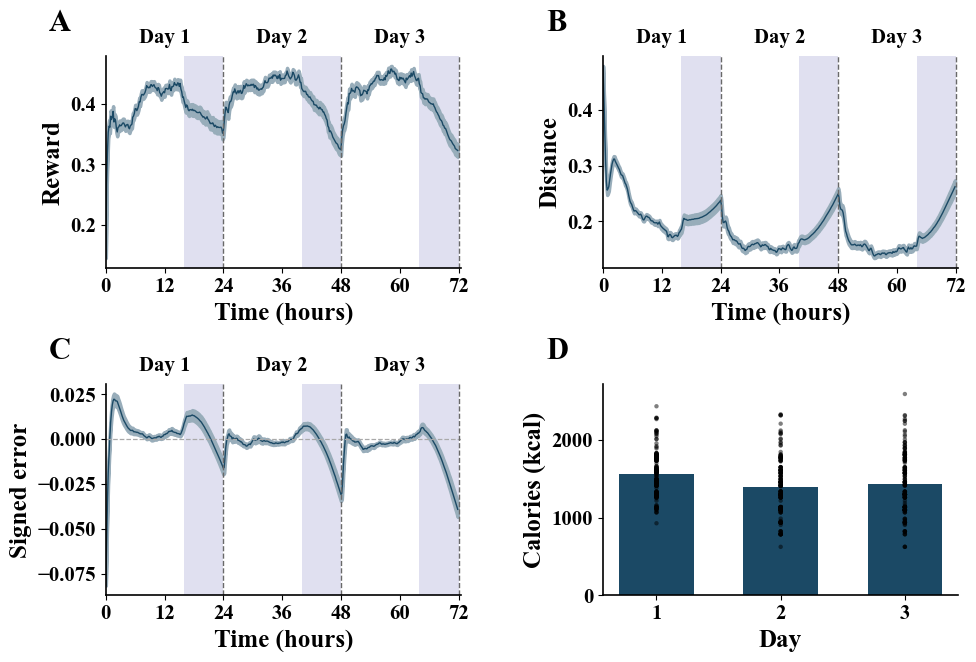

In [3]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE 2.1 — reward / distance / signed error (lines) + calories (bar)
# ══════════════════════════════════════════════════════════════════════
import pickle
import matplotlib.colors as mcolors

INF_DIR   = Path("results") / "plots_inference_normal"
PLOTS_DIR = Path("plots")/ "plots_inference"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

perstep = pd.read_pickle(INF_DIR / "inference_perstep_stats.pkl")
cal_day = pd.read_pickle(INF_DIR / "calories_per_day.pkl")

# ── time axis ─────────────────────────────────────────────────────────
AWAKE_STEPS, SLEEP_STEPS = 96, 48
AWAKE_HRS,   SLEEP_HRS   = 16, 8
STEPS_PER_HOUR = AWAKE_STEPS / AWAKE_HRS
TOTAL_HOURS    = len(perstep) / STEPS_PER_HOUR

def lighten(color, amount):
    r, g, b = mcolors.to_rgb(color)
    return (r + (1 - r) * amount,
            g + (1 - g) * amount,
            b + (1 - b) * amount)

SLEEP_COLOR = lighten("navy", 0.88)

def shade_sleep(ax, is_awake, scale=STEPS_PER_HOUR, first_label=True):
    a = np.asarray(is_awake).astype(bool)
    in_sleep, start, first = False, 0, first_label

    for t, awake in enumerate(a):
        if not awake and not in_sleep:
            in_sleep, start = True, t
        elif awake and in_sleep:
            ax.axvspan(start/scale, t/scale,
                       color=SLEEP_COLOR, lw=0, zorder=0,
                       label="Sleep" if first else None)
            first = False
            in_sleep = False

    if in_sleep:
        ax.axvspan(start/scale, len(a)/scale,
                   color=SLEEP_COLOR, lw=0, zorder=0,
                   label="Sleep" if first else None)

# ── add day labels ────────────────────────────────────────────────────
def add_day_labels(ax):
    day_centers = [12, 36, 60]
    day_labels  = ["Day 1", "Day 2", "Day 3"]

    for x, lab in zip(day_centers, day_labels):
        ax.text(
            x, 1.04, lab,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=15,
            fontweight="bold",
        )

    # day boundaries
    for x in [24, 48, 72]:
        ax.axvline(x, color="dimgray", ls="--", lw=1.0, alpha=1.0)

PANEL_LABEL_SIZE = 22
BAND_LIGHTEN     = 0.55
LINE_W           = 1.0

# Fig 2 = normal model → all panels use the normal (blue) condition colour
c_reward = c_distance = c_signed = c_cal = C_NORMAL

hours    = perstep["step"].values / STEPS_PER_HOUR
is_awake = perstep["is_awake"].values

HOUR_TICKS = np.arange(0, TOTAL_HOURS + 1, 12)

fig, ((ax_reward, ax_distance),
      (ax_signed, ax_cal)) = plt.subplots(2, 2, figsize=(11, 7))

fig.subplots_adjust(wspace=0.4, hspace=0.55)

# ──────────────────────────────────────────────────────────────────────
# A. Reward
# ──────────────────────────────────────────────────────────────────────
mu = perstep["reward_mean"].values
se = perstep["reward_sem"].values

shade_sleep(ax_reward, is_awake)
ax_reward.fill_between(hours, mu-se, mu+se,
                       color=lighten(c_reward, BAND_LIGHTEN),
                       lw=2.5, zorder=1,)
ax_reward.plot(hours, mu, color=c_reward, lw=LINE_W, zorder=2)

ax_reward.set_xlabel("Time (hours)")
ax_reward.set_ylabel("Reward")
ax_reward.set_xlim(0, TOTAL_HOURS)
ax_reward.set_xticks(HOUR_TICKS)
ax_reward.spines[["top", "right"]].set_visible(False)

add_day_labels(ax_reward)

ax_reward.text(-0.16, 1.22, "A",
               transform=ax_reward.transAxes,
               fontsize=PANEL_LABEL_SIZE,
               fontweight="bold",
               va="top", ha="left")

# ──────────────────────────────────────────────────────────────────────
# B. Distance
# ──────────────────────────────────────────────────────────────────────
mu = perstep["distance_mean"].values
se = perstep["distance_sem"].values

shade_sleep(ax_distance, is_awake)
ax_distance.fill_between(hours, mu-se, mu+se,
                         color=lighten(c_distance, BAND_LIGHTEN),
                         lw=2.5, zorder=1)
ax_distance.plot(hours, mu, color=c_distance, lw=LINE_W, zorder=2)

ax_distance.set_xlabel("Time (hours)")
ax_distance.set_ylabel("Distance")
ax_distance.set_xlim(0, TOTAL_HOURS)
ax_distance.set_xticks(HOUR_TICKS)
ax_distance.spines[["top", "right"]].set_visible(False)

add_day_labels(ax_distance)

ax_distance.text(-0.16, 1.22, "B",
                 transform=ax_distance.transAxes,
                 fontsize=PANEL_LABEL_SIZE,
                 fontweight="bold",
                 va="top", ha="left")

# ──────────────────────────────────────────────────────────────────────
# C. Signed error
# ──────────────────────────────────────────────────────────────────────
mu = perstep["signed_error_mean"].values
se = perstep["signed_error_sem"].values

shade_sleep(ax_signed, is_awake)
ax_signed.fill_between(hours, mu-se, mu+se,
                       color=lighten(c_signed, BAND_LIGHTEN),
                       lw=2.5, zorder=1)
ax_signed.plot(hours, mu, color=c_signed, lw=LINE_W, zorder=2)

ax_signed.axhline(0, color="darkgrey", lw=0.9, ls="--", alpha=1.0)

ax_signed.set_xlabel("Time (hours)")
ax_signed.set_ylabel("Signed error")
ax_signed.set_xlim(0, TOTAL_HOURS)
ax_signed.set_xticks(HOUR_TICKS)
ax_signed.spines[["top", "right"]].set_visible(False)

add_day_labels(ax_signed)

ax_signed.text(-0.16, 1.22, "C",
               transform=ax_signed.transAxes,
               fontsize=PANEL_LABEL_SIZE,
               fontweight="bold",
               va="top", ha="left")


# ──────────────────────────────────────────────────────────────────────
# D. Calories
# ──────────────────────────────────────────────────────────────────────
cal_ep = pd.read_pickle(INF_DIR / "calories_per_episode.pkl")   # (episodes, days)
days   = cal_day["day"].values

ax_cal.bar(days,
           cal_day["mean_kcal"].values,
        #    yerr=cal_day["sem_kcal"].values,
           color=c_cal,
           width=0.6,
           capsize=5,
           error_kw=dict(ecolor="black", elinewidth=1.3),
           zorder=2)

# all per-episode data points as jittered scatter
rng = np.random.default_rng(0)
for k, col in enumerate(cal_ep.columns):
    xj = days[k] * np.ones(len(cal_ep))#+ rng.uniform(-0.18, 0.18, size=len(cal_ep))
    ax_cal.scatter(xj, cal_ep[col].values, s=10, color="black",
                   alpha=0.50, edgecolors="none", zorder=3)

ax_cal.set_xlabel("Day")
ax_cal.set_ylabel("Calories (kcal)")
ax_cal.set_xticks(days)
# ax_cal.set_xticklabels([f"Day-{d}" for d in days])
ax_cal.spines[["top", "right"]].set_visible(False)

ax_cal.text(-0.16, 1.22, "D",
            transform=ax_cal.transAxes,
            fontsize=PANEL_LABEL_SIZE,
            fontweight="bold",
            va="top", ha="left")

for axes in [ax_reward, ax_distance, ax_signed]:
    axes.set_xlim(0,72.5)
# ──────────────────────────────────────────────────────────────────────
# Save
# ──────────────────────────────────────────────────────────────────────
save_fig(fig, "fig2_inference", "fig2_1_inference_summary")

plt.show()

/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_5220/1417413486.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", frameon=False, fontsize=12)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig2_inference/fig2_2_representative_nutrients.[png|pdf|svg|eps]


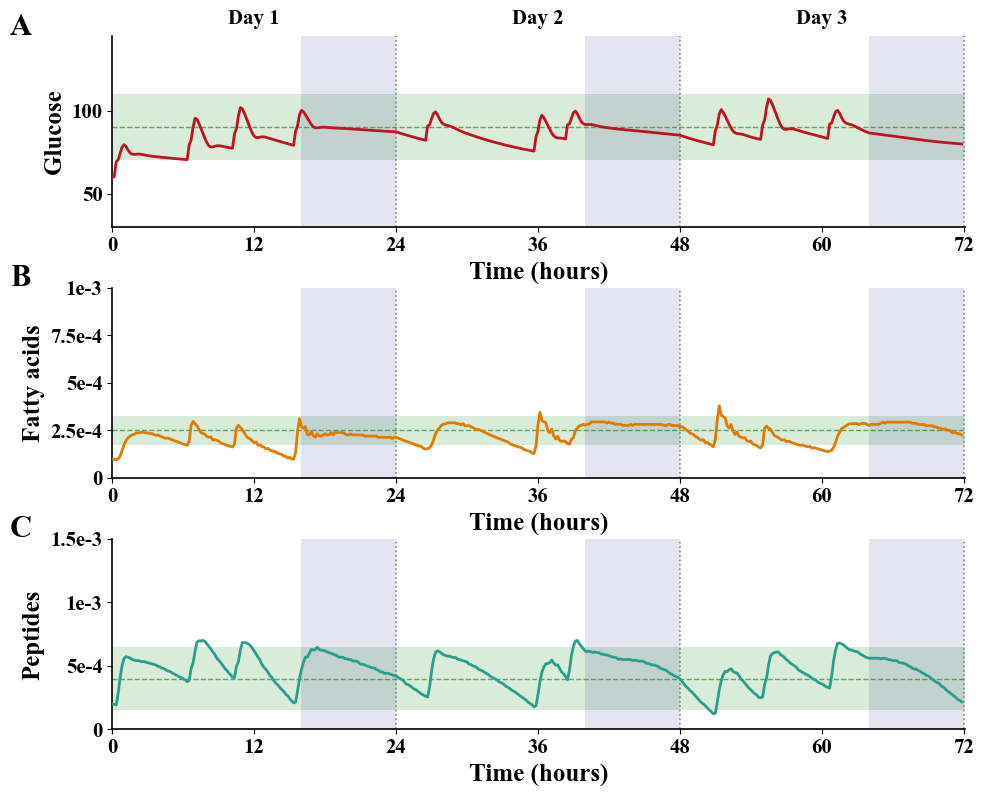

In [4]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE 2.2 — representative episode, raw-unit nutrient traces (3 rows)
#  inference-style alpha shading; green target zone; raw units only
# ══════════════════════════════════════════════════════════════════════
from matplotlib.ticker import FuncFormatter

rep = pd.read_pickle(INF_DIR / "representative_episode.pkl")   # dict

t        = rep["t"]
hours    = t / STEPS_PER_HOUR              # env steps -> hours
TOTAL_H  = len(t) / STEPS_PER_HOUR         # ~72 h (3 days)
phy_raw  = rep["phy_raw"]                  # (T, 3) raw units
names    = list(rep["nutrient_names"])
minmax   = rep["nutrient_minmax"]
tgt_low  = rep["target_low"]               # normalised, in `names` order
tgt_high = rep["target_high"]
tgt_mid  = rep["target_norm"]              # normalised target centre
sleep    = rep["sleep_windows"]            # (start, end) in steps

TARGET_COLOR = "green"                      # green target zone (alpha fill + dashed centre)

def sci_fmt(v, _):
    """Format small y-ticks as 2e-4 etc."""
    if v == 0:
        return "0"
    exp  = int(np.floor(np.log10(abs(v))))
    mant = v / 10**exp
    return f"{mant:g}e{exp}"

def shade_sleep_hours(ax, windows, scale=STEPS_PER_HOUR, color="navy", alpha=0.10):
    for k, (ws, we) in enumerate(windows):
        ax.axvspan(ws / scale, we / scale, color=color, alpha=alpha, lw=0, zorder=0,
                   )

def add_day_labels(ax, show_text=True):
    if show_text:
        for x, lab in zip([12, 36, 60], ["Day 1", "Day 2", "Day 3"]):
            ax.text(x, 1.04, lab, transform=ax.get_xaxis_transform(),
                    ha="center", va="bottom", fontsize=15, fontweight="bold")
    for x in [24, 48, 72]:
        ax.axvline(x, color="dimgray", ls=":", lw=1.2, alpha=0.8, zorder=2)

DISPLAY = {
    "glucose":     ("Glucose",          "mg/dl"),
    "fatty_acids": ("Fatty acids", "g"),
    "peptides":    ("Peptides",   "g"),
}
PLOT_ORDER = ["glucose", "fatty_acids", "peptides"]
ROW_COLORS = {"glucose": "#c1121f", "fatty_acids": "#e07a00", "peptides": "#2a9d8f"}
PANEL_LETTERS = ["A", "B", "C"]
HOUR_TICKS = np.arange(0, TOTAL_H + 1, 12)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=False)
fig.subplots_adjust(hspace=0.32)

y_lim_min = [30,0, 0]
y_lim_max = [145,10e-4, 15e-4]
num = 0
for ax, nm, letter in zip(axes, PLOT_ORDER, PANEL_LETTERS):
    i = names.index(nm)
    label, unit = DISPLAY[nm]
    vmin, vmax = minmax[nm]
    rng = vmax - vmin
    color = ROW_COLORS[nm]

    # green target zone (alpha) + dashed target centre, raw units
    ax.axhspan(tgt_low[i] * rng + vmin, tgt_high[i] * rng + vmin,
               color=TARGET_COLOR, alpha=0.15, lw=0, zorder=0)
    ax.axhline(tgt_mid[i] * rng + vmin, ls="--", color=TARGET_COLOR, lw=1.0, alpha=0.6, zorder=1)
    shade_sleep_hours(ax, sleep)
    ax.plot(hours, phy_raw[:, i], color=color, lw=2.0, zorder=3)

    add_day_labels(ax, show_text=(letter == "A"))
    ax.set_ylabel(f"{label}")
    ax.set_xlim(0, TOTAL_H+0.1)
    ax.set_xticks(HOUR_TICKS)
    ax.spines[["top", "right"]].set_visible(False)

    # scientific-notation y-ticks for the small-value panels (B, C)
    if nm != "glucose":
        ax.yaxis.set_major_formatter(FuncFormatter(sci_fmt))

    ax.text(-0.12, 1.12, letter, transform=ax.transAxes,
            fontsize=22, fontweight="bold", va="top", ha="left")
    if letter == "A":
        ax.legend(loc="upper right", frameon=False, fontsize=12)

    ax.set_ylim(y_lim_min[num], y_lim_max[num])
    num+= 1
    ax.set_xlabel("Time (hours)")

# axes[-1].set_xlabel("Time (hours)")

save_fig(fig, "fig2_inference", "fig2_2_representative_nutrients")

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig2_inference/fig2_2_representative_nutrients_eatticks.[png|pdf|svg|eps]


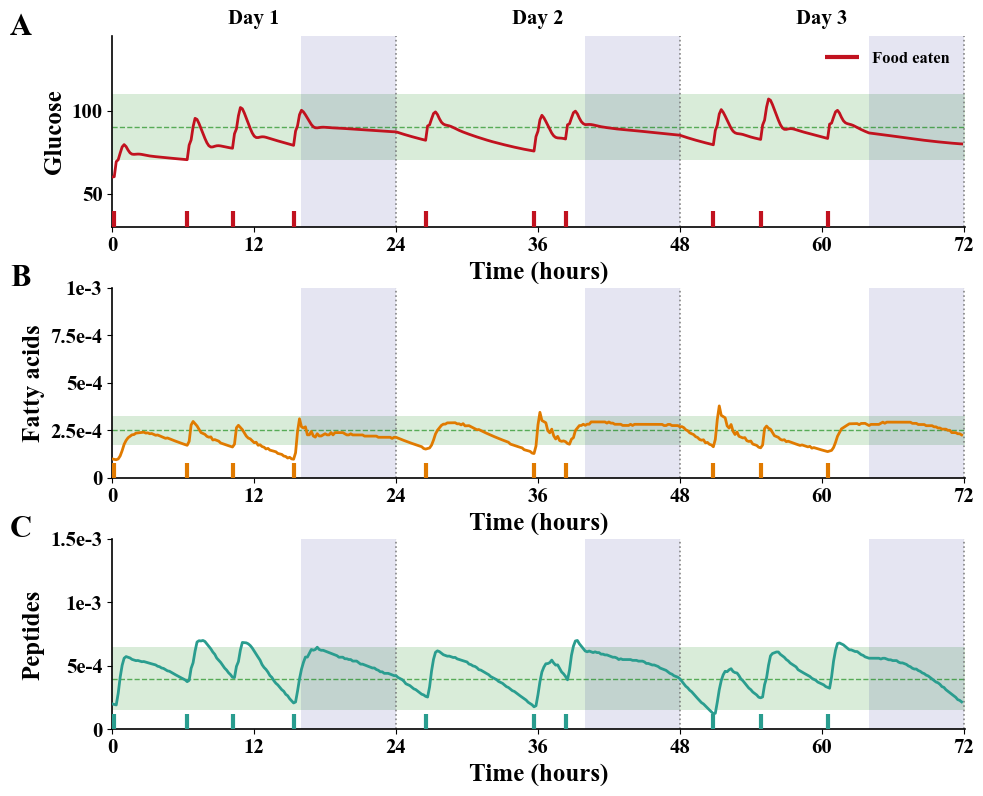

In [5]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE 2.2 — representative episode, raw-unit nutrient traces (3 rows)
#  inference-style alpha shading; green target zone; raw units only
#  + eating events drawn as bottom "|" ticks (same style as Fig 4)
# ══════════════════════════════════════════════════════════════════════
from matplotlib.ticker import FuncFormatter
from matplotlib.transforms import blended_transform_factory

rep = pd.read_pickle(INF_DIR / "representative_episode.pkl")   # dict

t        = rep["t"]
hours    = t / STEPS_PER_HOUR              # env steps -> hours
TOTAL_H  = len(t) / STEPS_PER_HOUR         # ~72 h (3 days)
phy_raw  = rep["phy_raw"]                  # (T, 3) raw units
names    = list(rep["nutrient_names"])
minmax   = rep["nutrient_minmax"]
tgt_low  = rep["target_low"]               # normalised, in `names` order
tgt_high = rep["target_high"]
tgt_mid  = rep["target_norm"]              # normalised target centre
sleep    = rep["sleep_windows"]            # (start, end) in steps
eat_h    = rep["eat_steps"] / STEPS_PER_HOUR   # eating events -> hours

TARGET_COLOR = "green"                      # green target zone (alpha fill + dashed centre)

def sci_fmt(v, _):
    """Format small y-ticks as 2e-4 etc."""
    if v == 0:
        return "0"
    exp  = int(np.floor(np.log10(abs(v))))
    mant = v / 10**exp
    return f"{mant:g}e{exp}"

def shade_sleep_hours(ax, windows, scale=STEPS_PER_HOUR, color="navy", alpha=0.10):
    for k, (ws, we) in enumerate(windows):
        ax.axvspan(ws / scale, we / scale, color=color, alpha=alpha, lw=0, zorder=0,
                   )

def add_day_labels(ax, show_text=True):
    if show_text:
        for x, lab in zip([12, 36, 60], ["Day 1", "Day 2", "Day 3"]):
            ax.text(x, 1.04, lab, transform=ax.get_xaxis_transform(),
                    ha="center", va="bottom", fontsize=15, fontweight="bold")
    for x in [24, 48, 72]:
        ax.axvline(x, color="dimgray", ls=":", lw=1.2, alpha=0.8, zorder=2)

DISPLAY = {
    "glucose":     ("Glucose",          "mg/dl"),
    "fatty_acids": ("Fatty acids", "g"),
    "peptides":    ("Peptides",   "g"),
}
PLOT_ORDER = ["glucose", "fatty_acids", "peptides"]
ROW_COLORS = {"glucose": "#c1121f", "fatty_acids": "#e07a00", "peptides": "#2a9d8f"}
PANEL_LETTERS = ["A", "B", "C"]
HOUR_TICKS = np.arange(0, TOTAL_H + 1, 12)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=False)
fig.subplots_adjust(hspace=0.32)

y_lim_min = [30,0, 0]
y_lim_max = [145,10e-4, 15e-4]
num = 0
for ax, nm, letter in zip(axes, PLOT_ORDER, PANEL_LETTERS):
    i = names.index(nm)
    label, unit = DISPLAY[nm]
    vmin, vmax = minmax[nm]
    rng = vmax - vmin
    color = ROW_COLORS[nm]

    # green target zone (alpha) + dashed target centre, raw units
    ax.axhspan(tgt_low[i] * rng + vmin, tgt_high[i] * rng + vmin,
               color=TARGET_COLOR, alpha=0.15, lw=0, zorder=0)
    ax.axhline(tgt_mid[i] * rng + vmin, ls="--", color=TARGET_COLOR, lw=1.0, alpha=0.6, zorder=1)
    shade_sleep_hours(ax, sleep)
    ax.plot(hours, phy_raw[:, i], color=color, lw=2.0, zorder=3)

    # eating events as bottom "|" ticks (Fig 4 style): x in data (hours), y in axes fraction
    tr = blended_transform_factory(ax.transData, ax.transAxes)
    ax.vlines(eat_h, 0.0, 0.08, transform=tr, color=color, lw=3.0, zorder=4,
              label="Food eaten")

    add_day_labels(ax, show_text=(letter == "A"))
    ax.set_ylabel(f"{label}")
    ax.set_xlim(0, TOTAL_H+0.1)
    ax.set_xticks(HOUR_TICKS)
    ax.spines[["top", "right"]].set_visible(False)

    # scientific-notation y-ticks for the small-value panels (B, C)
    if nm != "glucose":
        ax.yaxis.set_major_formatter(FuncFormatter(sci_fmt))

    ax.text(-0.12, 1.12, letter, transform=ax.transAxes,
            fontsize=22, fontweight="bold", va="top", ha="left")
    if letter == "A":
        ax.legend(loc="upper right", frameon=False, fontsize=12)

    ax.set_ylim(y_lim_min[num], y_lim_max[num])
    num+= 1
    ax.set_xlabel("Time (hours)")

save_fig(fig, "fig2_inference", "fig2_2_representative_nutrients_eatticks")

plt.show()

# Figure-3 — Latent analysis

Uses the latent/decoding data saved by `infer_run.ipynb` in
`results/plots_inference_normal/` (seed 0, best checkpoint, 200 inference
episodes). Nothing here is recomputed.

- **3.1 (appendix)** 4x4 grid: the 16 bottleneck latent neurons over the
  representative episode, with food-eating instances marked (hours axis, sleep
  shaded).
- **3.2** Latent decoding of hunger / fullness — one cell for the **linear** fit
  and one for the **polynomial** fit. Each is a 2x2 grid: top = true vs held-out
  prediction time series (sleep shaded, hours), bottom = pooled predicted-vs-true
  scatter with R^2.


/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_5220/2215274357.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend(loc="upper right", fontsize=9, frameon=False)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig3_latent/fig3_1_latent_neurons.[png|pdf|svg|eps]


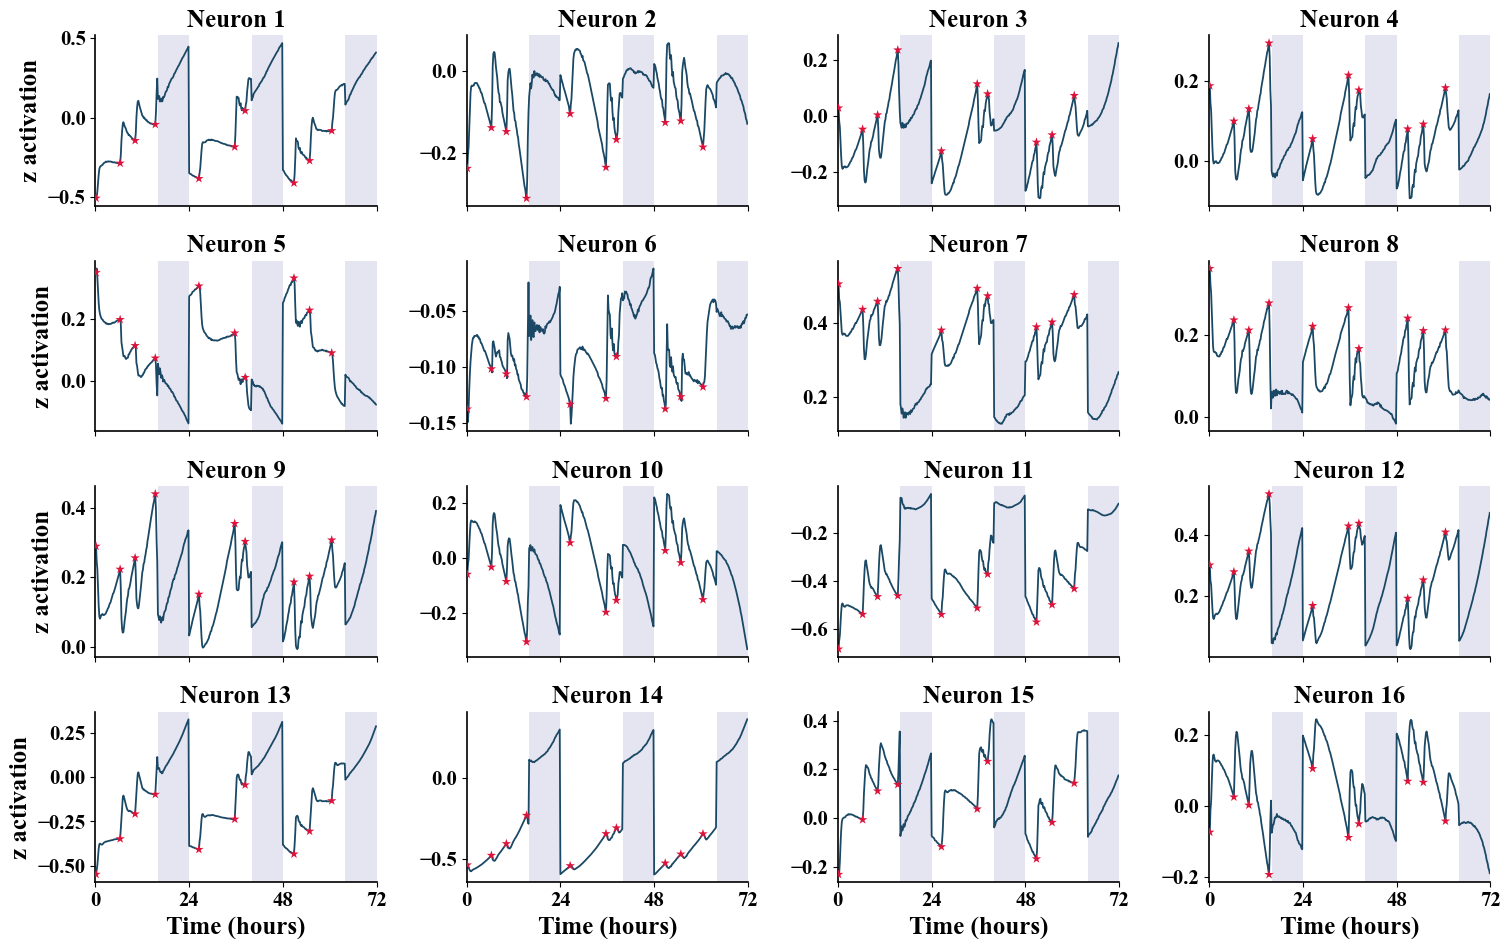

In [6]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE 3.1 (appendix) — 16 bottleneck latent neurons + eating instances
# ══════════════════════════════════════════════════════════════════════
import matplotlib.colors as mcolors

INF_DIR   = Path("results") / "plots_inference_normal"
PLOTS_DIR = Path("plots") / "plots_inference"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

STEPS_PER_HOUR = 96 / 16          # 6 steps/hour (16 h awake + 8 h asleep = 144 steps/day)

def shade_sleep_hours(ax, windows, scale=STEPS_PER_HOUR, color="navy", alpha=0.10, label=True):
    for k, (ws, we) in enumerate(windows):
        ax.axvspan(ws/scale, we/scale, color=color, alpha=alpha, lw=0, zorder=0,
                   )

rep       = pd.read_pickle(INF_DIR / "representative_episode.pkl")
t         = rep["t"]
hours     = t / STEPS_PER_HOUR
TOTAL_H   = len(t) / STEPS_PER_HOUR
z         = rep["z_phy"]                       # (T, 16)
ate       = rep["ate"].astype(bool)
sleep     = rep["sleep_windows"]
eat_steps = np.where(ate)[0]
eat_h     = eat_steps / STEPS_PER_HOUR

fig, axes = plt.subplots(4, 4, figsize=(18, 11), sharex=True)
fig.subplots_adjust(hspace=0.32, wspace = 0.32)
for j, ax in enumerate(axes.ravel()):
    shade_sleep_hours(ax, sleep, label=(j == 0))
    ax.plot(hours, z[:, j], color=C_NORMAL, lw=1.3, zorder=2)
    ax.scatter(eat_h, z[eat_steps, j], s=50, color="crimson", zorder=4, edgecolors="none", marker = '*',
               )
    # ax.axhline(0, color="grey", lw=0.8, ls="--", alpha=0.6)
    ax.set_title(f"Neuron {j+1}")
    ax.set_xlim(0, TOTAL_H)
    ax.set_xticks([0, 24, 48, 72])
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[-1, :]:
    ax.set_xlabel("Time (hours)")
for ax in axes[:, 0]:
    ax.set_ylabel("z activation")
axes[0, 0].legend(loc="upper right", fontsize=9, frameon=False)

# fig.tight_layout()
save_fig(fig, "fig3_latent", "fig3_1_latent_neurons")
plt.show()


In [7]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE 3.2 — latent decoding of hunger / fullness (2x2)
#  top: true vs held-out prediction (time series)   bottom: pooled pred-vs-true
# ══════════════════════════════════════════════════════════════════════
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

scores = pd.read_pickle(INF_DIR / "decode_scores.pkl")        # r2 per (target, fit)
dp     = pd.read_pickle(INF_DIR / "decode_predictions.pkl")   # pooled true/pred (86400)
pool   = pd.read_pickle(INF_DIR / "pooled_capture.pkl")       # pooled is_awake (86400)

# ── choices ────────────────────────────────────────────────────────────
COLOR_BY_DAY = True      # True -> colour scatter by day (awake=filled, sleep=open)
                         # False -> single colour per target
N_SAMPLES    = 4000      # how many scatter points to plot (None = all)

# ── reconstruct day (1/2/3) + awake/sleep for each pooled point ─────────
T_EP, CYCLE = 432, 144
_N         = len(dp["episode_idx"])
_step_ep   = np.tile(np.arange(T_EP), _N // T_EP)
day_pool   = _step_ep // CYCLE + 1                 # 1, 2, 3
awake_pool = pool["is_awake"].astype(bool)
DAY_COLORS = {1: "#0072B2", 2: "#E69F00", 3: "#009E73"}   # colourblind-safe

def latent_fit_figure(mode):
    TARGETS = ["hunger", "fullness"]
    TCOL    = {"hunger": "#c1121f", "fullness": "#1b4965"}

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.subplots_adjust(wspace=0.4, hspace=0.5)

    for col, tgt in enumerate(TARGETS):
        key = f"{tgt}|{mode}"
        d   = rep["decode"][key]
        r2  = float(scores[(scores.target == tgt) &
                           (scores.fit == mode)]["r2_cv"].iloc[0])

        # ──────────────────────────────────────────────────────────────
        # Top row: representative time series
        # ──────────────────────────────────────────────────────────────
        ax = axes[0, col]

        shade_sleep_hours(ax, sleep, label=(col == 0))

        ax.plot(hours, d["true"],
                color="black", lw=1.6, label="True")

        ax.plot(hours, d["pred_oof"],
                color="darkviolet", lw=1.5, ls="--",
                label="Predicted")

        ax.scatter(eat_h,
                   d["true"][eat_steps],
                   s=100,
                   color="crimson",
                   marker="*",
                   edgecolors="none",
                   zorder=5,
                   label="Food eaten")

        ax.set_xlim(0, TOTAL_H)
        ax.set_xticks([0, 24, 48, 72])
        ax.set_xlabel("Time (hours)")
        ax.set_ylabel(tgt.capitalize())
        ax.spines[["top", "right"]].set_visible(False)
        for x in [24, 48, 72]:
            ax.axvline(x, color="dimgray", ls="--", lw=1.0, zorder=0)
        
        # Day labels
        for x, label in zip([12, 36, 60], ["Day 1", "Day 2", "Day 3"]):
            ax.text(
                x,
                1.02,
                label,
                transform=ax.get_xaxis_transform(),  # x in data coords, y in axes coords
                ha="center",
                va="bottom",
                fontsize=14,
                fontweight="bold",
                color="black",
            )


        ax.set_xlim(0, TOTAL_H + 0.1)

        # ──────────────────────────────────────────────────────────────
        # Bottom row: pooled prediction scatter
        # ──────────────────────────────────────────────────────────────
        ax = axes[1, col]

        yt = dp["targets"][key]["true"]
        yp = dp["targets"][key]["pred_oof"]

        ok = ~np.isnan(yp)

        lims = [
            np.nanmin([yt[ok].min(), yp[ok].min()]),
            np.nanmax([yt[ok].max(), yp[ok].max()])
        ]

        idx = np.where(ok)[0]
        if N_SAMPLES is not None and N_SAMPLES < len(idx):
            idx = np.sort(
                np.random.default_rng(0).choice(
                    idx, N_SAMPLES, replace=False
                )
            )

        if COLOR_BY_DAY:
            for day in (1, 2, 3):

                aw = idx[(day_pool[idx] == day) &
                         awake_pool[idx]]

                sl = idx[(day_pool[idx] == day) &
                         ~awake_pool[idx]]

                ax.scatter(
                    yt[aw], yp[aw],
                    s=25,
                    color=DAY_COLORS[day],
                    marker='.',
                    alpha=1.0,
                    edgecolors="none",
                    label=f"Day {day}",
                )

                ax.scatter(
                    yt[sl], yp[sl],
                    s=25,
                    facecolors=DAY_COLORS[day],
                    marker='.',
                    alpha=0.55,
                    edgecolors="none",
                )

        else:
            ax.scatter(
                yt[idx], yp[idx],
                s=5,
                alpha=0.20,
                color=TCOL[tgt],
                edgecolors="none",
            )

        ax.plot(
            lims,
            lims,
            color="black",
            ls="--",
            lw=1.2,
            label="y = x",
        )

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xlabel(f"True {tgt}")
        ax.set_ylabel(f"Predicted {tgt}")
        ax.spines[["top", "right"]].set_visible(False)

        mse = float(scores[(scores.target == tgt) &
                           (scores.fit == mode)]["mse_cv"].iloc[0])

        r = float(scores[(scores.target == tgt) &
                         (scores.fit == mode)]["r_cv"].iloc[0])

        print(f"{tgt:9s} [{mode:6s}]  held-out R2={r2:.3f}  "
              f"MSE={mse:.5f}  r={r:+.3f}")

    # ==========================================================
    # Shared legend for TOP ROW
    # ==========================================================
    top_handles = [
        Line2D([0], [0], color="black", lw=1.6, label="True"),
        Line2D([0], [0], color="darkviolet", lw=1.5,
               ls="--", label="Predicted"),
        Line2D([0], [0], marker="*", color="crimson",
               linestyle="None", markersize=12,
               label="Food eaten"),
        Patch(facecolor="0.90", edgecolor="none",
              label="Sleep"),
    ]

    fig.legend(
        handles=top_handles,
        loc="center",
        bbox_to_anchor=(0.5, 0.475),
        ncol=4,
        frameon=False,
        fontsize=15,
    )

    # ==========================================================
    # Shared legend for BOTTOM ROW
    # ==========================================================
    if COLOR_BY_DAY:
        bottom_handles = [
            Line2D([0], [0], marker='.', color=DAY_COLORS[1],
                   linestyle='None', markersize=20, label='Day 1'),
            Line2D([0], [0], marker='.', color=DAY_COLORS[2],
                   linestyle='None', markersize=20, label='Day 2'),
            Line2D([0], [0], marker='.', color=DAY_COLORS[3],
                   linestyle='None', markersize=20, label='Day 3'),
            Line2D([0], [0], color='black',
                   ls='--', lw=1.2, label='y = x'),
        ]
    else:
        bottom_handles = [
            Line2D([0], [0], color='black',
                   ls='--', lw=1.2, label='y = x')
        ]

    fig.legend(
        handles=bottom_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.055),
        ncol=len(bottom_handles),
        frameon=False,
        fontsize=15,
    )

    # Panel labels
    for ax, lab in zip(axes.ravel(), ["A", "B", "C", "D"]):
        ax.text(
            -0.12, 1.12, lab,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            ha="left",
        )

    # Leave room for shared legends
    # fig.tight_layout(rect=[0, 0.05, 1, 0.95])

    save_fig(fig, "fig3_latent", f"fig3_2_latent_fit_{mode}")

    return fig

hunger    [linear]  held-out R2=0.429  MSE=0.01323  r=+0.655
fullness  [linear]  held-out R2=0.569  MSE=0.00986  r=+0.754


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig3_latent/fig3_2_latent_fit_linear.[png|pdf|svg|eps]


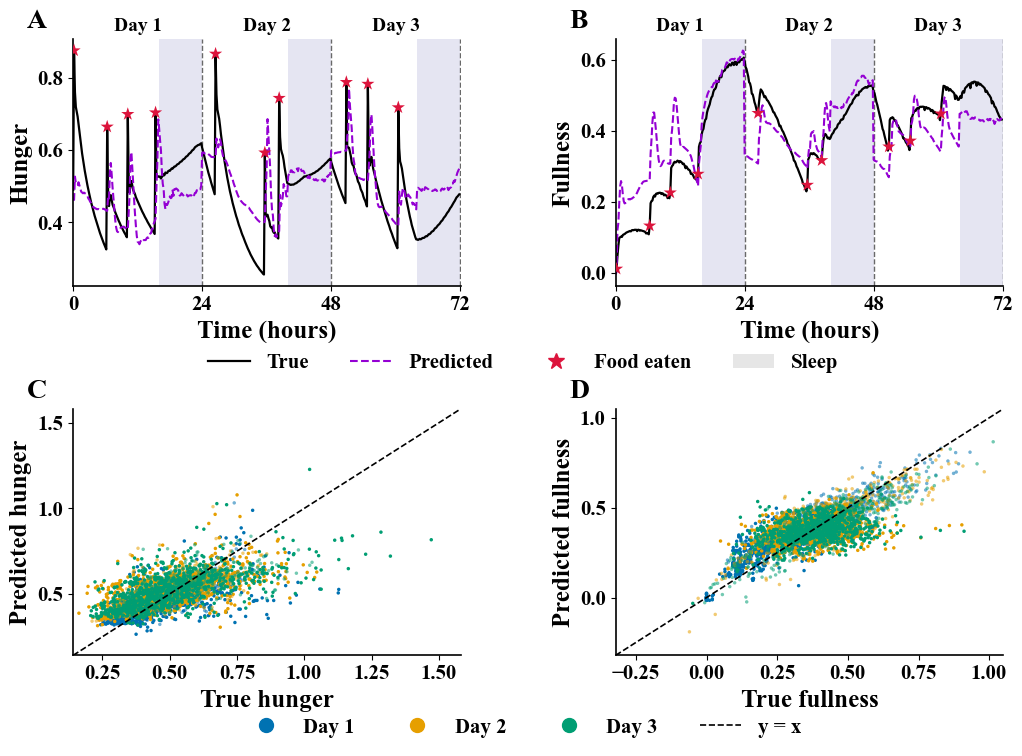

In [8]:
latent_fit_figure("linear")
plt.show()


hunger    [poly  ]  held-out R2=0.578  MSE=0.00976  r=+0.761
fullness  [poly  ]  held-out R2=0.659  MSE=0.00781  r=+0.812


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig3_latent/fig3_2_latent_fit_poly.[png|pdf|svg|eps]


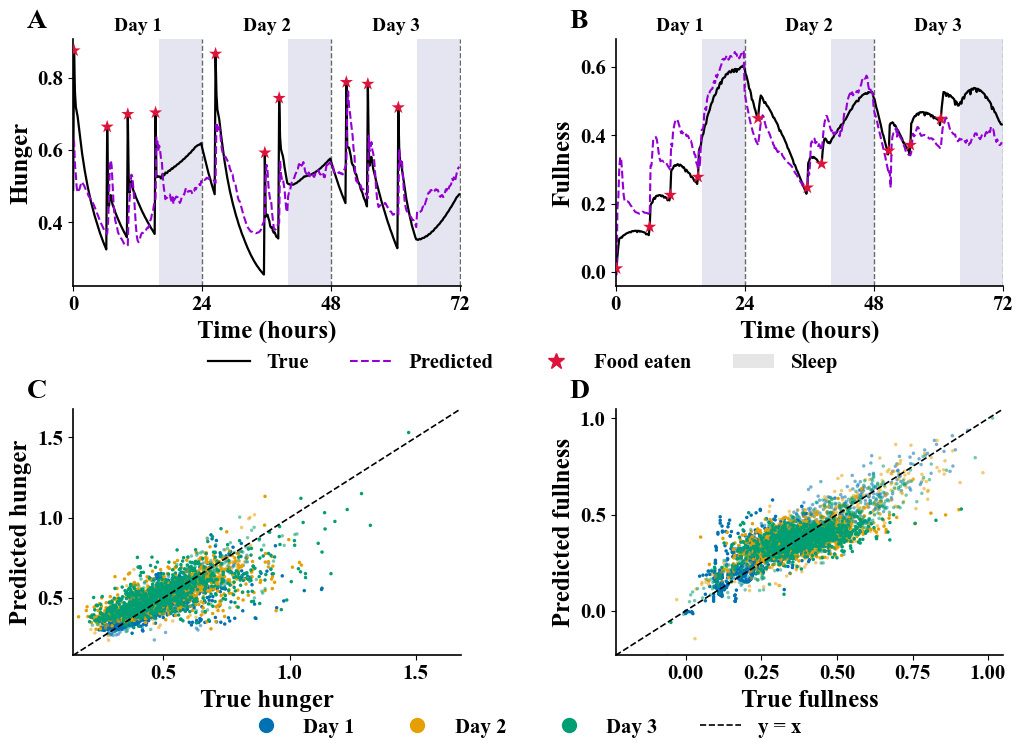

In [9]:
# ── FIGURE 3.2 — polynomial fit (same layout, reuses latent_fit_figure) ──
latent_fit_figure("poly")
plt.show()


# Figure 4 — Latent view ablation (3D nutrient-space trajectories)

Uses `results/plots_latent_ablation/conditions_capture.pkl` (pooled over SEEDS x N_INFERENCE; representative
best-return rollout per condition). Each nutrient is a normalised axis; trajectories are coloured
light -> dark over time, **solid = awake / dashed = sleep**, food-eaten steps are
starred, and the target region is shown as a translucent box + hollow sphere.

Conditions are discovered from the data by bias sign: most-negative bias = under-eating,
`baseline` (bias 0), most-positive bias = over-eating.

Two cells: (a) all conditions in one 3D axes, (b) one 3D panel per condition.

> **Note on interpretation:** this shows a single *randomly chosen* rollout per condition (not the best-return one). It is one example draw, so it need not equal the pooled averages; the calorie bars in the Fig-4 summary cell are means over all pooled sims. Re-running the capture (or setting `REP_PICK_SEED=None`) draws a different random example.

In [10]:
# ══════════════════════════════════════════════════════════════════════
#  3D nutrient-space trajectories — setup + COMBINED plot (all conditions)
#  Conditions are discovered from the pickle by BIAS SIGN, so this is robust
#  to the bias magnitudes changing between runs (e.g. -1.05/+1.75 vs ±1.15).
# ══════════════════════════════════════════════════════════════════════
from mpl_toolkits.mplot3d.art3d import Line3DCollection, Poly3DCollection
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

LAT_DIR   = Path("results") / "plots_latent_ablation"
PLOTS_DIR = Path("plots") / "plots_latent_ablation"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

cc    = pd.read_pickle(LAT_DIR / "conditions_capture.pkl")
meta  = cc["meta"]; runs = cc["runs"]
names = meta["nutrient_names"]                          # e.g. ['glucose','peptides','fatty_acids']
low, high, ctr = meta["target_low"], meta["target_high"], meta["target_norm"]
sleep_wins = meta["sleep_windows"]
AX_LABELS = ["Glucose", "Peptides", "Fatty acids"]

# ── discover conditions by bias sign (baseline / under-eating / over-eating) ──
_bias  = {lab: float(r["bias"]) for lab, r in runs.items()}
_base  = next((l for l, b in _bias.items() if abs(b) < 1e-6),
              min(_bias, key=lambda l: abs(_bias[l])))
_under = min(_bias, key=lambda l: _bias[l])            # most negative -> under-eating
_over  = max(_bias, key=lambda l: _bias[l])            # most positive -> over-eating
COND_MAP = {
    _base:  ("Baseline",     plt.cm.Blues),
    _under: ("Under-eating", plt.cm.Oranges),
    _over:  ("Over-eating",  plt.cm.Reds),
}
ORDER = [_base, _under, _over]
T_EP  = int(np.asarray(runs[_base]["phy_representative"]).shape[0])
print("Conditions:", {l: COND_MAP[l][0] for l in ORDER},
      "| bias:", {l: round(_bias[l], 3) for l in ORDER}, "| T =", T_EP)

def _awake_mask(T, wins):
    a = np.ones(T, bool)
    for s, e in wins:
        a[s:e] = False
    return a
AWAKE = _awake_mask(T_EP, sleep_wins)

def draw_target(ax):
    """Nested translucent ellipsoids (light->dark toward centre) at the target."""
    c = (low + high) / 2.0
    a0 = (high - low) / 2.0 * 1.75        # outer semi-axes
    u, v = np.mgrid[0:2*np.pi:24j, 0:np.pi:16j]

    shells = [(1.00, "#32A432", 0.10),      # (scale, colour, alpha)  outer, light
              (0.66, "#3FA23F", 0.13),      # middle
              (0.34, "#083C08", 0.16)]      # inner, dark
    for sc, col, al in shells:
        a = a0 * sc
        xs = c[0] + a[0]*np.cos(u)*np.sin(v)
        ys = c[1] + a[1]*np.sin(u)*np.sin(v)
        zs = c[2] + a[2]*np.cos(v)
        ax.plot_surface(xs, ys, zs, color=col, alpha=al, linewidth=0, shade=False, zorder=0)
    ax.scatter([ctr[0]], [ctr[1]], [ctr[2]], color="#1B6B1B", s=30, marker="o", zorder=1)

def plot_traj(ax, phy, color, eat_steps, lw=1.0):
    """Solid uniform-colour 3D line (solid=awake, dashed=sleep) + food-eaten stars."""
    base = mcolors.to_rgb(color)
    pts  = phy.reshape(-1, 1, 3)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    styles = ["solid" if AWAKE[i] else "dashed" for i in range(len(segs))]
    lc = Line3DCollection(segs, colors=base, linestyles=styles, linewidths=lw, zorder=5, alpha = 0.75)
    ax.add_collection3d(lc)
    ax.scatter(phy[eat_steps, 0], phy[eat_steps, 1], phy[eat_steps, 2],
               marker="*", s=40, color=base, depthshade=False, zorder=6)
    ax.grid(True)

def set3d(ax):
    ax.set_xlabel(AX_LABELS[0]); ax.set_ylabel(AX_LABELS[1]); ax.set_zlabel(AX_LABELS[2])
    ax.set_xlim(-0.15, 1.0); ax.set_ylim(-0.3, 0.9); ax.set_zlim(-0.05, 0.8)
    ax.view_init(elev=22, azim=-60)


Conditions: {'baseline': 'Baseline', 'bias=-1': 'Under-eating', 'bias=+1.5': 'Over-eating'} | bias: {'baseline': 0.0, 'bias=-1': -1.0, 'bias=+1.5': 1.5} | T = 432


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig4_ablation/fig4_1_ablation_journal_raw.[png|pdf|svg|eps]


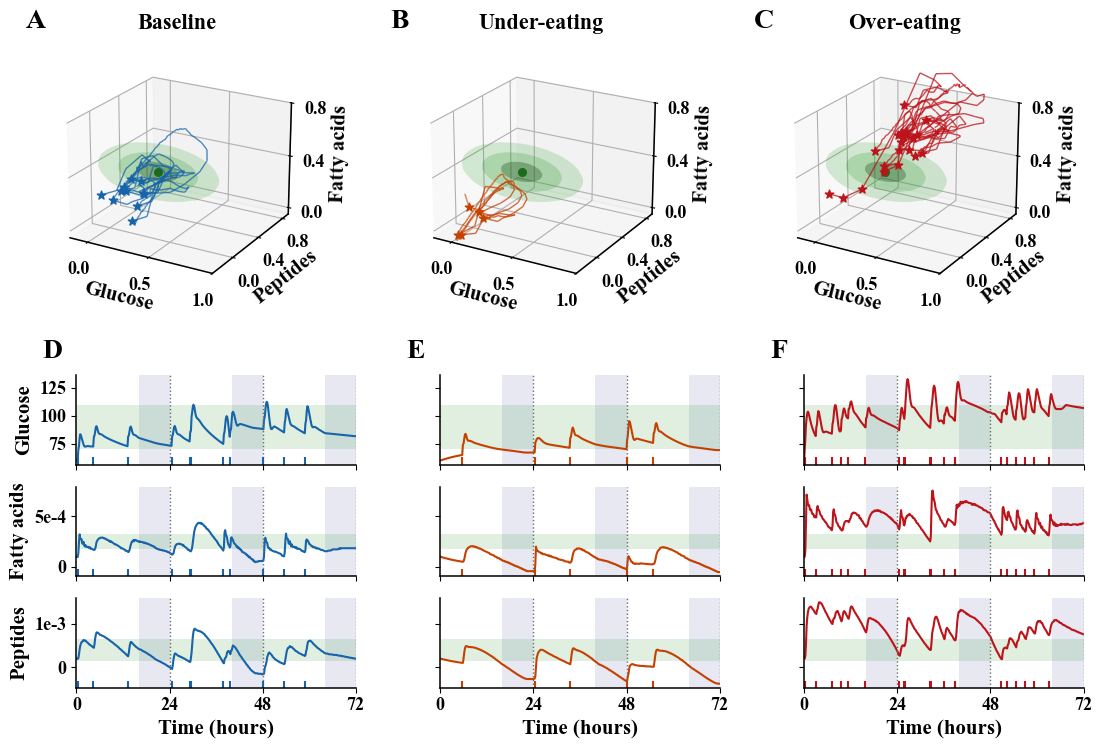

In [11]:
# ══════════════════════════════════════════════════════════════════════
#  Journal figure — columns = condition
#  row 1 (tall): 3D nutrient-space trajectory (A/B/C)
#  rows 2-4: raw nutrient dynamics stacked (glucose / fatty acids / peptides),
#            shared y per nutrient across conditions; eaten events merged as
#            thick short ticks at each panel base; fatty-acids/peptides ticks
#            in 1e-4 format; label D/E/F
#  (reuses helpers/data from the combined 3D cell above)
# ══════════════════════════════════════════════════════════════════════
from matplotlib.transforms import blended_transform_factory
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({"font.family":"serif","font.serif":["Times New Roman","DejaVu Serif"],
    "font.weight":"bold","axes.labelweight":"bold","axes.titleweight":"bold",
    "font.size":14,"axes.titlesize":16,"axes.labelsize":15,"xtick.labelsize":13,"ytick.labelsize":13,"axes.linewidth":1.1})

minmax=meta["nutrient_minmax"]; low_n=meta["target_low"]; high_n=meta["target_high"]
STEPS_PER_HOUR=6; TOTAL_H=432/STEPS_PER_HOUR; hours=np.arange(432)/STEPS_PER_HOUR
NUT_ROWS=["glucose","fatty_acids","peptides"]
NUT_NICE={"glucose":"Glucose","fatty_acids":"Fatty acids","peptides":"Peptides"}
SCI_ROWS={"fatty_acids","peptides"}
L3D=["A","B","C"]; LBOT=["D","E","F"]

def sci_fmt(v,_):
    if v==0: return "0"
    exp=int(np.floor(np.log10(abs(v)))); m=v/10**exp
    return f"{m:g}e{exp}"
def raw(nm,v):
    vmin,vmax=minmax[nm]; return v*(vmax-vmin)+vmin
def shade_h(ax):
    for s,e in sleep_wins: ax.axvspan(s/STEPS_PER_HOUR,e/STEPS_PER_HOUR,color="navy",alpha=0.09,lw=0)
def day_lines(ax):
    for x in (24,48,72): ax.axvline(x,color="dimgray",lw=1.0,ls=":")

fig=plt.figure(figsize=(13,9))
gs=fig.add_gridspec(4,3,height_ratios=[4,1,1,1],hspace=0.14,wspace=0.30)
row_ref={}; colx={}
for k,lab in enumerate(ORDER):
    nice,cmap=COND_MAP[lab]; col=cmap(0.8)
    phy=runs[lab]["phy_representative"]; eat_h=runs[lab]["eat_steps"]/STEPS_PER_HOUR
    ax=fig.add_subplot(gs[0,k],projection="3d",computed_zorder=False)
    draw_target(ax); plot_traj(ax,phy,col,runs[lab]["eat_steps"]); set3d(ax)
    ax.set_xticks([0,0.5,1.0]); ax.set_yticks([0,0.4,0.8]); ax.set_zticks([0,0.4,0.8])
    ax.set_box_aspect(None, zoom=0.9)          # shrink content so right z-axis label fits
    _p = ax.get_position(); ax.set_position([_p.x0 - 0.03, _p.y0, _p.width, _p.height])  # nudge 3D panel left
    ax.set_title(nice,pad=0)
    ax.text2D(-0.04,1.0,L3D[k],transform=ax.transAxes,fontsize=20,fontweight="bold",va="bottom",ha="left")
    for ri,nm in enumerate(NUT_ROWS):
        i=names.index(nm)
        ax=fig.add_subplot(gs[1+ri,k], sharey=row_ref.get(nm), sharex=colx.get(k))
        if nm not in row_ref: row_ref[nm]=ax
        if k not in colx: colx[k]=ax
        shade_h(ax)
        ax.axhspan(raw(nm,low_n[i]),raw(nm,high_n[i]),color="green",alpha=0.12,lw=0)
        ax.plot(hours,raw(nm,phy[:,i]),color=col,lw=1.5)
        day_lines(ax)
        tr=blended_transform_factory(ax.transData,ax.transAxes)
        ax.vlines(eat_h,0.0,0.08,transform=tr,color=col,lw=1.5)
        ax.set_xlim(0,TOTAL_H+0.1); ax.set_xticks([0,24,48,72])
        ax.spines[["top","right"]].set_visible(False)
        if ri<2: plt.setp(ax.get_xticklabels(),visible=False)
        else: ax.set_xlabel("Time (hours)")
        if k==0:
            ax.set_ylabel(NUT_NICE[nm])
            if nm in SCI_ROWS: ax.yaxis.set_major_formatter(FuncFormatter(sci_fmt))
        else:
            plt.setp(ax.get_yticklabels(),visible=False)
        if ri==0:
            ax.text(-0.12,1.12,LBOT[k],transform=ax.transAxes,fontsize=20,fontweight="bold",va="bottom",ha="left")

save_fig(fig, "fig4_ablation", "fig4_1_ablation_journal_raw")
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig4_ablation/fig4_2_summary_no_bias.[png|pdf|svg|eps]


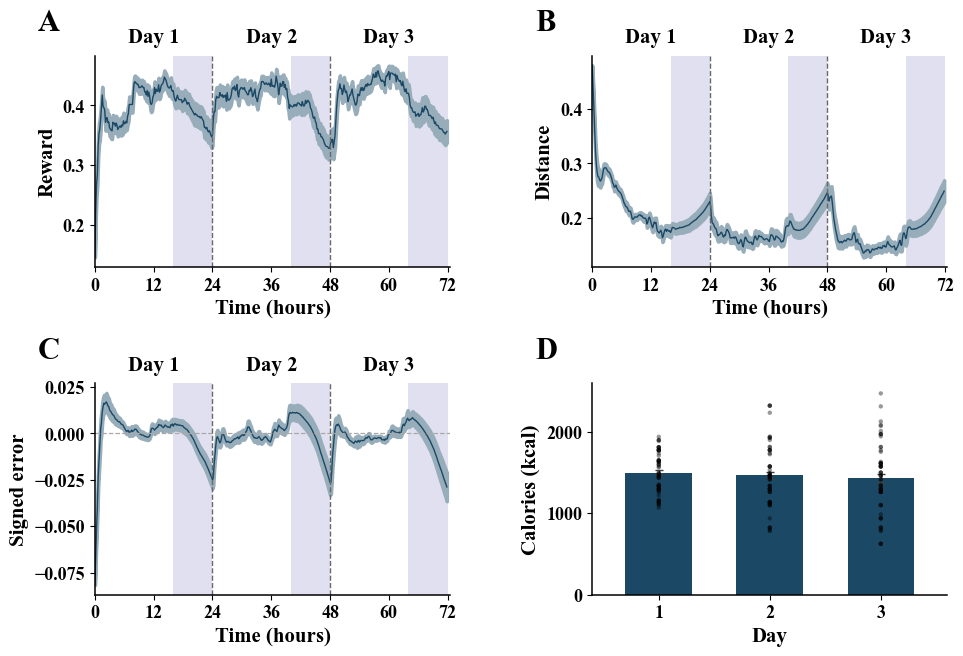

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig4_ablation/fig4_2_summary_low_bias.[png|pdf|svg|eps]


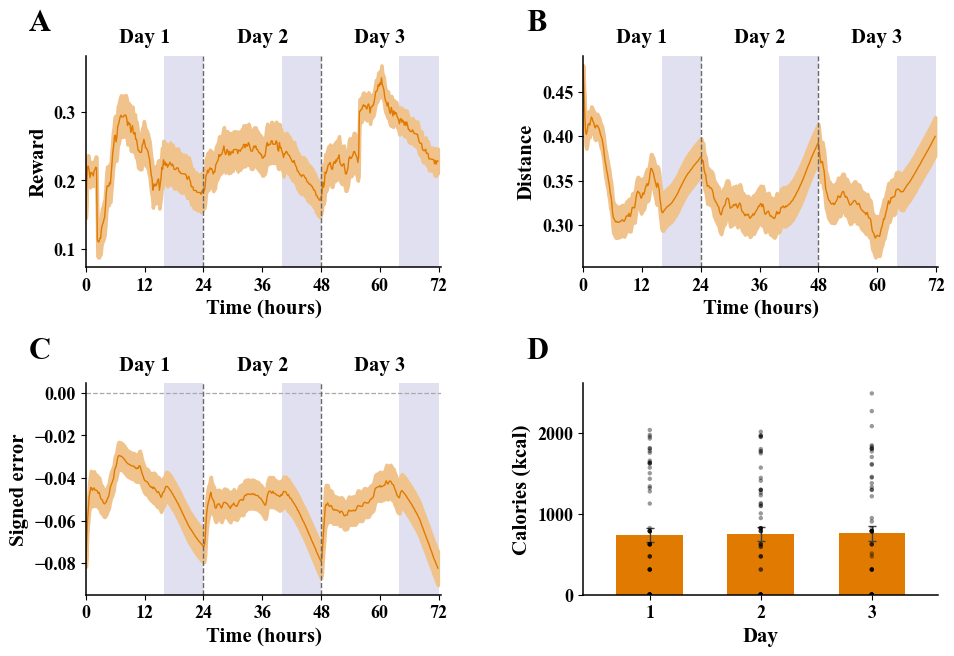

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig4_ablation/fig4_2_summary_high_bias.[png|pdf|svg|eps]


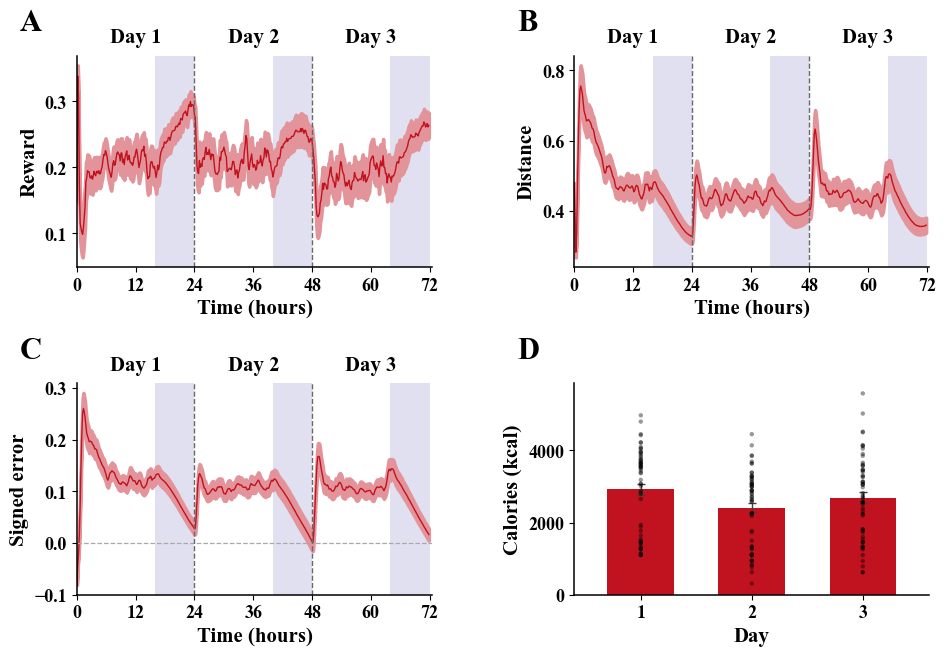

In [12]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE 4-style summary — per bias case (no / low / high bias)
#  Reward · Distance · Signed error (per-step mean±SE) + Calories per day
#  A/B/C -> results/plots_latent_ablation/perstep_by_condition.pkl (pooled mean/sem)
#  D     -> conditions_capture 'cal_per_day' (pooled SEEDS x N_INFERENCE),
#           bars = mean±SEM over sims + per-sim scatter  (same as TD Fig 5.2-D)
#  Conditions discovered from the data; robust to bias-magnitude changes.
# ══════════════════════════════════════════════════════════════════════
import warnings
import matplotlib.colors as mcolors

LAT_DIR = Path("results") / "plots_latent_ablation"
perstep_all = pd.read_pickle(LAT_DIR / "perstep_by_condition.pkl")   # long-form mean/sem
per_ep_all  = pd.read_pickle(LAT_DIR / "per_episode_by_condition.pkl")
_cc         = pd.read_pickle(LAT_DIR / "conditions_capture.pkl")
_meta       = _cc["meta"]; _runs = _cc["runs"]

# ── discover the three conditions from the per-step table ───────────────
_cond_bias = (perstep_all[["condition", "bias"]]
              .drop_duplicates().set_index("condition")["bias"])
_base = "baseline" if "baseline" in _cond_bias.index else _cond_bias.abs().idxmin()
CASES = [                                            # (nice name, condition key)
    ("no bias",   _base),
    ("low bias",  _cond_bias.idxmin()),             # most negative bias (under-eating)
    ("high bias", _cond_bias.idxmax()),             # most positive bias (over-eating)
]

# ── config (T / days / sleep derived from the saved data) ───────────────
STEPS_PER_HOUR = 6
T_EP        = int(perstep_all["step"].max()) + 1
TOTAL_HOURS = T_EP / STEPS_PER_HOUR
hours       = np.arange(T_EP) / STEPS_PER_HOUR
HOUR_TICKS  = np.arange(0, TOTAL_HOURS + 1, 12)
SLEEP_WINS  = _meta["sleep_windows"]
N_DAYS      = int(round(TOTAL_HOURS / 24))

PANELS = [("rew", "Reward"), ("dist", "Distance"), ("signed", "Signed error")]
CASE_COLOR = {"no bias": C_NORMAL, "low bias": C_UNDER, "high bias": C_OVER}
BAND_LIGHTEN, LINE_W, PANEL_LABEL_SIZE = 0.55, 1.0, 22

def lighten(color, amount):
    r, g, b = mcolors.to_rgb(color)
    return (r + (1-r)*amount, g + (1-g)*amount, b + (1-b)*amount)

SLEEP_COLOR = lighten("navy", 0.88)

def shade_sleep(ax):
    for ws, we in SLEEP_WINS:
        ax.axvspan(ws/STEPS_PER_HOUR, we/STEPS_PER_HOUR, color=SLEEP_COLOR, lw=0, zorder=0)

def add_day_labels(ax):
    for d in range(N_DAYS):
        ax.text((d + 0.5) * 24, 1.04, f"Day {d+1}", transform=ax.get_xaxis_transform(),
                ha="center", va="bottom", fontsize=15, fontweight="bold")
    for d in range(1, N_DAYS):
        ax.axvline(d * 24, color="dimgray", ls="--", lw=1.0)

def panel_letter(ax, letter):
    ax.text(-0.16, 1.22, letter, transform=ax.transAxes,
            fontsize=PANEL_LABEL_SIZE, fontweight="bold", va="top", ha="left")

def _cal_per_day(key):
    """(n_sims, n_days) per-day kcal for a condition, pooled over SEEDS x N_INFERENCE."""
    run = _runs.get(key)
    if run is None or "cal_per_day" not in run:
        return None
    return np.asarray(run["cal_per_day"], dtype=float)

# ── one 4-panel figure per case ────────────────────────────────────────
def plot_case(nice, key):
    fig, ((ax_r, ax_d), (ax_s, ax_c)) = plt.subplots(2, 2, figsize=(11, 7))
    fig.subplots_adjust(wspace=0.4, hspace=0.55)
    axmap   = {"rew": ax_r, "dist": ax_d, "signed": ax_s}
    letters = {"rew": "A", "dist": "B", "signed": "C"}
    bias    = float(_cond_bias[key])
    cond_col = CASE_COLOR[nice]

    sub = perstep_all[perstep_all.condition == key]
    for metric, ylabel in PANELS:
        ax = axmap[metric]
        m  = sub[sub.metric == metric].sort_values("step")
        mu, se = m["mean"].values, m["sem"].values
        col = cond_col
        shade_sleep(ax)
        ax.fill_between(hours, mu-se, mu+se, color=lighten(col, BAND_LIGHTEN), lw=2.5, zorder=1)
        ax.plot(hours, mu, color=col, lw=LINE_W, zorder=2)
        if metric == "signed":
            ax.axhline(0, color="darkgrey", lw=0.9, ls="--")
        ax.set_xlabel("Time (hours)"); ax.set_ylabel(ylabel)
        ax.set_xlim(0, TOTAL_HOURS + 0.5); ax.set_xticks(HOUR_TICKS)
        ax.spines[["top", "right"]].set_visible(False)
        add_day_labels(ax); panel_letter(ax, letters[metric])

    # ── D. Calories per day: bars (mean±SEM over pooled sims) + per-sim scatter ──
    cm = _cal_per_day(key)
    if cm is not None:
        xd  = np.arange(1, cm.shape[1] + 1)
        cnt = np.sum(~np.isnan(cm), axis=0)
        dmean = np.nanmean(cm, axis=0)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            dstd = np.nanstd(cm, axis=0, ddof=1)
        dsem = np.where(cnt > 1, dstd / np.sqrt(np.maximum(cnt, 1)), 0.0)
        ax_c.bar(xd, dmean, yerr=dsem, capsize=3, color=cond_col, width=0.6,
                 error_kw=dict(lw=1.0, ecolor="0.25"), zorder=2)
        for s in range(cm.shape[0]):
            ax_c.scatter(xd, cm[s], s=10, color="black", alpha=0.4, edgecolors="none", zorder=3)
        ax_c.set_xticks(xd); ax_c.set_xlim(0.4, cm.shape[1] + 0.6)
    else:
        print(f"[panel D] '{key}': conditions_capture.pkl lacks 'cal_per_day' — "
              f"re-run the save cell in latent_ablations.ipynb.")
    ax_c.set_xlabel("Day"); ax_c.set_ylabel("Calories (kcal)")
    ax_c.spines[["top", "right"]].set_visible(False)
    panel_letter(ax_c, "D")


    save_fig(fig, "fig4_ablation", f"fig4_2_summary_{nice.replace(' ', '_')}")
    plt.show()

for nice, key in CASES:
    plot_case(nice, key)


### Fig 4 (supp) — All phy-bottleneck neurons under each bias condition

Three N×N grids (baseline / under-eating / over-eating) showing every bottleneck neuron's activation over the **same seed-42 example rollout** used by the Fig-4 nutrient trajectory and the z_phy grid. Food-consumed steps are starred; sleep windows shaded. Data: `conditions_capture.pkl` → `z_representative` / `ate_representative` (nothing recomputed).

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig4_ablation/fig4_3_supp_neurons_baseline.[png|pdf|svg|eps]


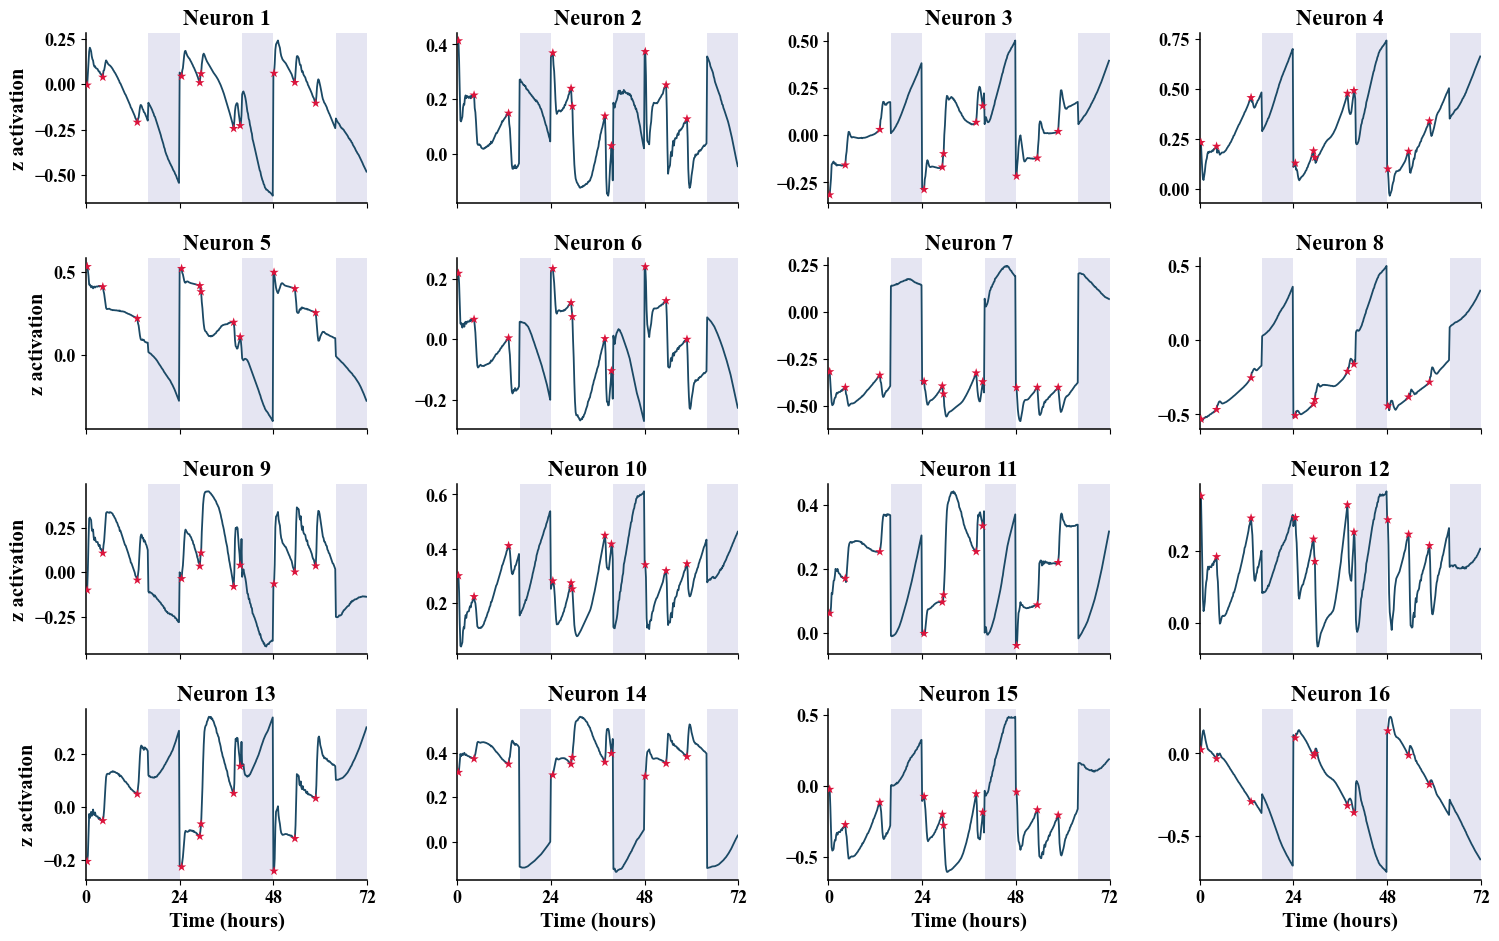

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig4_ablation/fig4_3_supp_neurons_under_eating.[png|pdf|svg|eps]


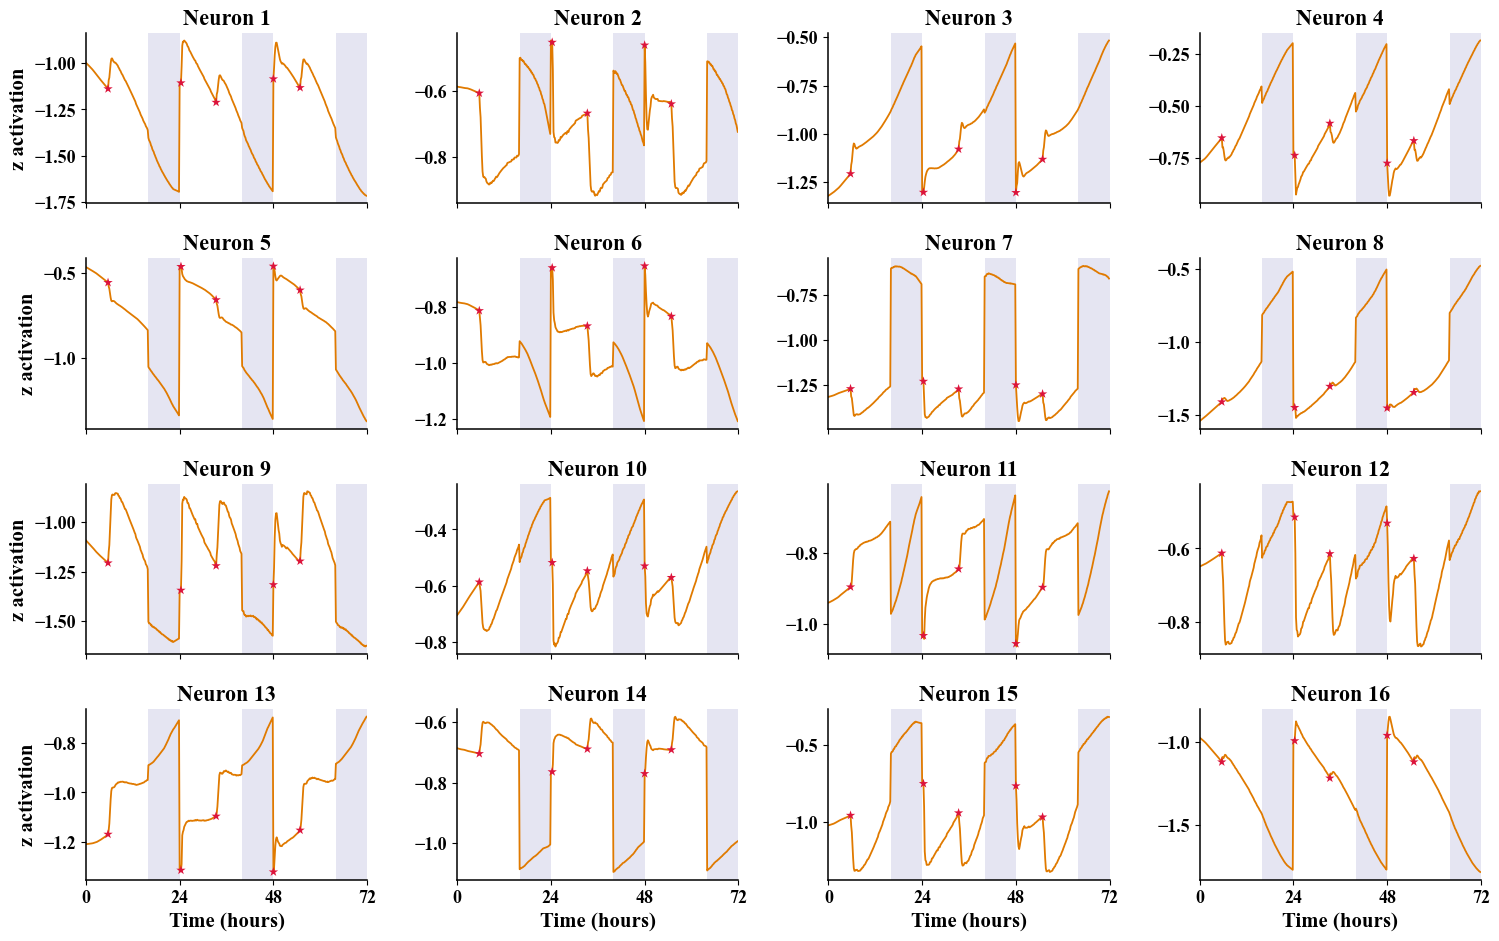

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig4_ablation/fig4_3_supp_neurons_over_eating.[png|pdf|svg|eps]


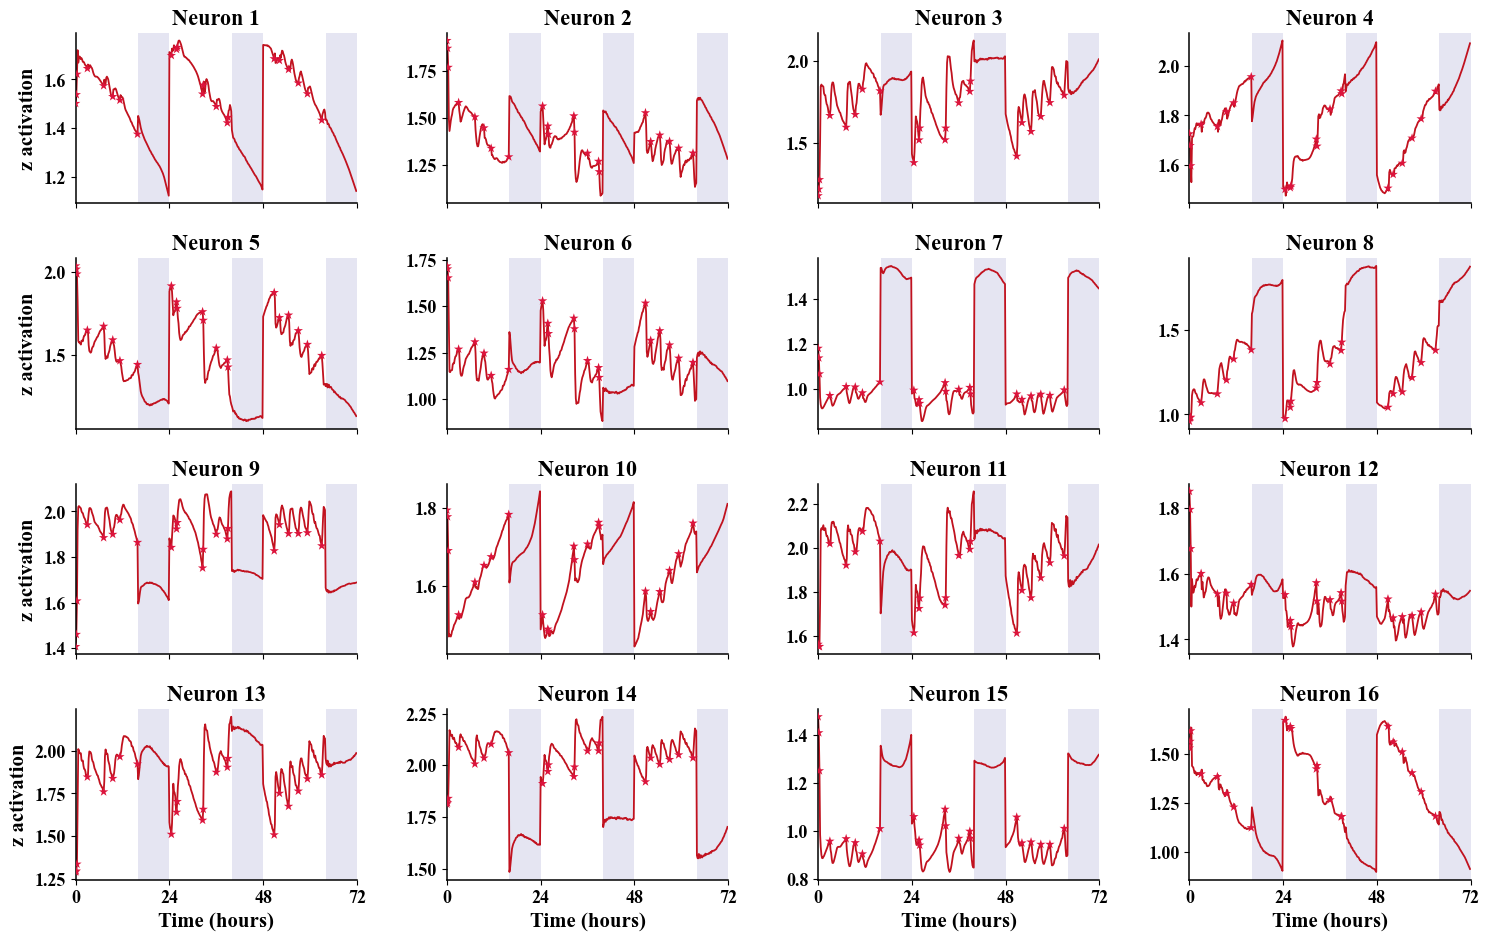

In [13]:
# ══════════════════════════════════════════════════════════════════════
#  Fig 4 (supp) — all phy-bottleneck neurons under each bias condition
#  one N x N grid per condition (baseline / under-eating / over-eating),
#  SAME seed-42 example rollout as the Fig-4 nutrient & z_phy plots.
#  data: conditions_capture.pkl -> z_representative / ate_representative
# ══════════════════════════════════════════════════════════════════════
LAT_DIR = Path("results") / "plots_latent_ablation"
cc   = pd.read_pickle(LAT_DIR / "conditions_capture.pkl")
runs = cc["runs"]; meta = cc["meta"]; sleep = meta["sleep_windows"]

z0 = np.asarray(next(iter(runs.values()))["z_representative"])
T_EP, Z_DIM   = z0.shape
STEPS_PER_HOUR = 6.0
hours   = np.arange(T_EP) / STEPS_PER_HOUR
TOTAL_H = T_EP / STEPS_PER_HOUR
NCOL = 4
NROW = int(np.ceil(Z_DIM / NCOL))

# discover conditions by bias sign (robust to bias magnitudes changing)
_bias  = {lab: float(r["bias"]) for lab, r in runs.items()}
_base  = next((l for l, b in _bias.items() if abs(b) < 1e-6), min(_bias, key=lambda l: abs(_bias[l])))
_under = min(_bias, key=lambda l: _bias[l])
_over  = max(_bias, key=lambda l: _bias[l])
COND_NICE  = {_base: "Baseline", _under: "Under-eating", _over: "Over-eating"}
COND_COLOR = {_base: C_NORMAL, _under: C_UNDER, _over: C_OVER}
ORDER      = [_base, _under, _over]

def shade_sleep_hours(ax, windows, scale=STEPS_PER_HOUR, color="navy", alpha=0.10):
    for ws, we in windows:
        ax.axvspan(ws/scale, we/scale, color=color, alpha=alpha, lw=0, zorder=0)

def neuron_grid(lab):
    z   = np.asarray(runs[lab]["z_representative"])              # (T, Z_DIM)
    ate = np.asarray(runs[lab]["ate_representative"]).astype(bool)
    eat = np.where(ate)[0]; eat_h = eat / STEPS_PER_HOUR
    col = COND_COLOR[lab]

    fig, axes = plt.subplots(NROW, NCOL, figsize=(4.5*NCOL, 2.75*NROW), sharex=True)
    fig.subplots_adjust(hspace=0.32, wspace=0.32)
    for j, ax in enumerate(axes.ravel()):
        if j >= Z_DIM:
            ax.axis("off"); continue
        shade_sleep_hours(ax, sleep)
        ax.plot(hours, z[:, j], color=col, lw=1.3, zorder=2)
        ax.scatter(eat_h, z[eat, j], s=50, color="crimson", zorder=4, edgecolors="none", marker="*")
        ax.set_title(f"Neuron {j+1}")
        ax.set_xlim(0, TOTAL_H); ax.set_xticks([0, 24, 48, 72])
        ax.spines[["top", "right"]].set_visible(False)
    for ax in axes[-1, :]:
        ax.set_xlabel("Time (hours)")
    for ax in axes[:, 0]:
        ax.set_ylabel("z activation")
    return fig

for lab in ORDER:
    fig = neuron_grid(lab)
    save_fig(fig, "fig4_ablation", f"fig4_3_supp_neurons_{COND_NICE[lab].lower().replace('-','_')}")
    plt.show()


# Figure 3.2 — Latent bias sweep

Sweeps the latent bias from negative to positive (30 values, ±1.5) and plots the
mean behaviour per bias: consumption/day, calories/day, reward/episode, distance to
target, and signed error. Orange region = under-eating (bias < 0), red = over-eating
(bias > 0); dotted line = baseline (bias = 0). Data: `bias_sweep.pkl`.

calories_sem
reward_sem
distance_sem
None


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig4_ablation/fig4_4_bias_sweep.[png|pdf|svg|eps]


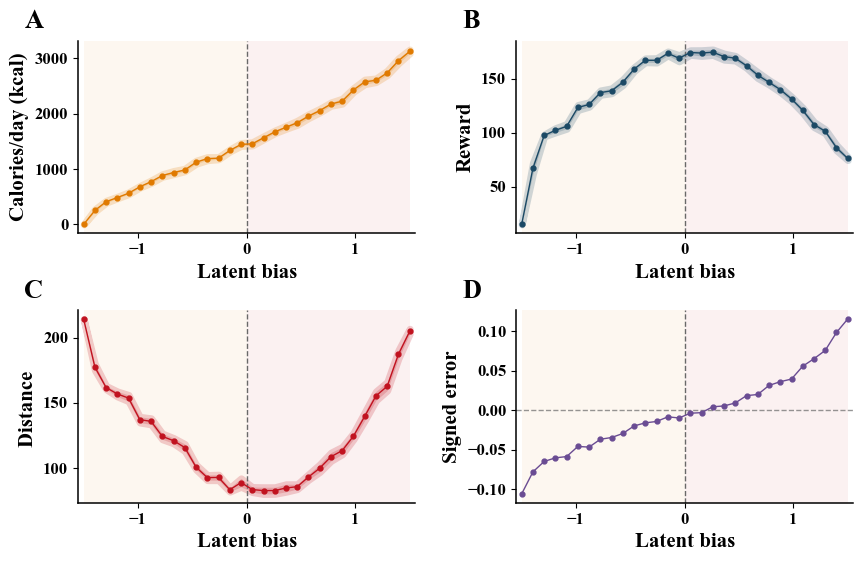

In [14]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE 3.2 — latent bias sweep
#  behaviour as latent bias goes from negative (under-eating) to positive
#  (over-eating): consumption, calories, reward, distance, signed error
#  data: results/plots_latent_ablation/bias_sweep.pkl  (nothing recomputed)
# ══════════════════════════════════════════════════════════════════════
plt.rcParams.update({"font.family":"serif","font.serif":["Times New Roman","DejaVu Serif"],
    "font.weight":"bold","axes.labelweight":"bold","axes.titleweight":"bold",
    "font.size":14,"axes.titlesize":15,"axes.labelsize":15,"xtick.labelsize":12,"ytick.labelsize":12,"axes.linewidth":1.1})

LAT_DIR=Path("results")/"plots_latent_ablation"
sw=pd.read_pickle(LAT_DIR/"bias_sweep.pkl").sort_values("value")
x=sw["value"].values

# (mean col, sem col or None, ylabel, colour)
DAYS_PER_EPISODE = 3   # convert per-episode totals to per-day
# (mean col, sem col or None, ylabel, colour, divisor)
PANELS=[
    ("calories_mean","calories_sem","Calories/day (kcal)","#e07a00", DAYS_PER_EPISODE),
    ("reward_mean","reward_sem","Reward","#1b4965", 1),
    ("distance_mean","distance_sem","Distance ","#c1121f", 1),
    ("signed_err_mean",None,"Signed error","#6a4c93", 1),
]
LETTERS=["A","B","C","D"]

fig,axes=plt.subplots(2,2,figsize=(10,6))
fig.subplots_adjust(
    wspace=0.3,   # horizontal spacing between columns
    hspace=0.4    # vertical spacing between rows
)
axes=axes.ravel()
for k,(mcol,scol,ylab,col,div) in enumerate(PANELS):
    print(scol)
    ax=axes[k]
    y=sw[mcol].values / div
    # under / over shading + baseline line
    ax.axvspan(x.min(),0,color=C_UNDER,alpha=0.06,lw=0)
    ax.axvspan(0,x.max(),color=C_OVER,alpha=0.06,lw=0)
    ax.axvline(0,color="dimgray",lw=1.0,ls="--")
    if mcol=="signed_err_mean":
        ax.axhline(0,color="dimgray",lw=1.0,ls="--",alpha=0.7)
    if scol is not None:
        se=sw[scol].values / div
        ax.fill_between(x,y-se,y+se,color=col,alpha=0.20,lw=5)
    ax.plot(x,y,color=col,lw=1.0,marker="o",ms=3.5)
    ax.set_xlabel("Latent bias")
    ax.set_ylabel(ylab)
    ax.set_xlim(x.min()-0.05,x.max()+0.05)
    ax.spines[["top","right"]].set_visible(False)
    ax.text(-0.16,1.16,LETTERS[k],transform=ax.transAxes,fontsize=19,fontweight="bold",va="top",ha="left")
# annotate under/over on the empty panel
# axes[-1].text(0.5,0.6,"Latent bias sweep",ha="center",fontsize=15,fontweight="bold")
# axes[-1].text(0.5,0.45,"bias $<$ 0  →  under-eating\nbias $>$ 0  →  over-eating",ha="center",fontsize=12)
# fig.tight_layout()
save_fig(fig, "fig4_ablation", "fig4_4_bias_sweep")
plt.show()


# Figure 5 — TD-clip retrain
Loads the saved bundles (`td_clip_retrain_conditions.pkl` for the 3 conditions; `td_clip_plot_data.pkl` for the clip sweep) — no model/torch needed. **Fig 5.3 requires re-running `td_clip_retrain.ipynb`** so its pkl carries `rep_eat_steps` + `minmax`.

In [15]:
# ══════════════════════════════════════════════════════════════════════
#  Figure 5 — TD-clip retrain (loads saved pkls; no model/torch needed)
# ══════════════════════════════════════════════════════════════════════
import os, glob, pickle, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

FIG5_DIR  = os.path.join('plots', 'fig5_td_clip'); os.makedirs(FIG5_DIR, exist_ok=True)
COND_PKL  = 'results/plots_td_clip_retrain/td_clip_retrain_conditions.pkl'  # 3 conditions (reqs 1,2,3)
SWEEP_PKL = 'results/plots_retrain/td_clip_plot_data.pkl'                    # clip sweep   (reqs 4,5)
PEREP_PKL = 'results/plots_retrain/inference_per_episode.pkl'               # freshest per-episode inference

cond_data = pickle.load(open(COND_PKL, 'rb'))
RES       = cond_data['results']
sweep     = pickle.load(open(SWEEP_PKL, 'rb'))

# condition order for Figs 5.1-5.3
COND_ORDER = ['no clip'] + [l for l, _ in cond_data['conditions'] if l != 'no clip']
COND_ORDER = [l for l in COND_ORDER if l in RES]
# no clip = normal (blue); +clip -> under-eating (orange); -clip -> over-eating (red)
CLR = {l: (C_NORMAL if 'no clip' in l else (C_UNDER if '+' in l else C_OVER))
       for l in COND_ORDER}

def _sleepwins(a):
    w, ins, s = [], False, 0
    for t, v in enumerate(a):
        if not v and not ins: ins, s = True, t
        elif v and ins: ins = False; w.append((s, t))
    if ins: w.append((s, len(a)))
    return w

# ── Rebuild severity frames (Figs 5.4/5.5) from the FRESHEST per-episode data ──
# Prefers inference_per_episode.pkl over the (possibly older) frames baked into
# td_clip_plot_data.pkl, so Fig 5.4/5.5 reflects every del-lim you've inferred
# without needing to re-run the plots-notebook save cell.
AGG_METRICS = [('signed_dist', 'Signed distance'), ('food_items', 'Consumption (food items)'),
               ('return', 'Return'), ('distance', 'Distance (L2)'), ('calories', 'Total calories (kcal)')]

def _dl_label(dl):
    if dl is None or (isinstance(dl, float) and (dl == 0 or np.isnan(dl))):
        return 'no clip'
    return f'{"+" if dl > 0 else "-"}{abs(float(dl)):g}'

def _severity_frame(df_subset, noclip_df):
    parts = pd.concat([noclip_df, df_subset], ignore_index=True); recs = []
    for (dl, sev), g in parts.groupby(['limit_delta', 'severity'], dropna=False):
        rec = {'limit_delta': dl, 'severity': sev, 'label': _dl_label(dl),
               'n_episodes': len(g), 'n_seeds': int(g['seed'].nunique())}
        for key, _ in AGG_METRICS:
            rec[f'{key}_mean'] = g[key].mean()
            rec[f'{key}_sem']  = g[key].std(ddof=1) / np.sqrt(len(g)) if len(g) > 1 else 0.0
        recs.append(rec)
    fr = pd.DataFrame(recs); fr['is_noclip'] = fr['severity'] == 0
    return fr.sort_values(['is_noclip', 'severity'], ascending=[True, True]).reset_index(drop=True)

def _ntags(df):
    return df['tag'].nunique() if (df is not None and 'tag' in getattr(df, 'columns', [])) else -1

_pkl_pe   = sweep.get('per_ep_df')
_fresh_pe = pd.read_pickle(PEREP_PKL) if os.path.exists(PEREP_PKL) else None
per_ep    = _fresh_pe if (_fresh_pe is not None and _ntags(_fresh_pe) >= _ntags(_pkl_pe)) else _pkl_pe
_src      = PEREP_PKL if per_ep is _fresh_pe else SWEEP_PKL

if per_ep is not None and 'sign' in per_ep.columns:
    _nc = per_ep[per_ep['sign'] == 0]
    sweep['severity_pos'] = _severity_frame(per_ep[per_ep['sign'] > 0], _nc)
    sweep['severity_neg'] = _severity_frame(per_ep[per_ep['sign'] < 0], _nc)
    sweep['per_ep_df']    = per_ep
    print(f'Severity frames rebuilt from {os.path.basename(_src)}  ({_ntags(per_ep)} del-lim tags)')

print('Conditions loaded :', COND_ORDER)
print('Sweep frames       :', [k for k in ('severity_pos', 'severity_neg') if k in sweep])

# ── Freshness check vs the del-lim folders actually on disk ────────────────
_root = sweep.get('config', {}).get('RETRAIN_ROOT', 'results/retrain_500ep')
_disk = {p.split(os.sep)[-3]
         for p in glob.glob(os.path.join(_root, '*', 'checkpoints_retrain_*', 'retrain_info.json'))}
_have = set(per_ep['tag'].unique()) if (per_ep is not None and 'tag' in per_ep.columns) else set()
_missing = sorted(_disk - _have)
if _missing:
    print(f'\n[!] {len(_missing)} del-lim folder(s) on disk NOT in the inference data:')
    print('    ', _missing)
    print('    Fix: re-run the INFERENCE cell in td_clip_retrain_plots.ipynb (regenerates')
    print(f'         inference_per_episode.pkl), then re-run THIS load cell.')
else:
    print(f'\n[ok] inference data covers all {len(_disk)} del-lim folders under {_root}.')

Severity frames rebuilt from inference_per_episode.pkl  (36 del-lim tags)
Conditions loaded : ['no clip', '-severe (-1e-05)', '+severe (+1e-05)']
Sweep frames       : ['severity_pos', 'severity_neg']

[ok] inference data covers all 36 del-lim folders under results/retrain_500ep.


### Fig 5.1 — Training curves (3 conditions overlaid)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig5_td_clip/fig5_1_training_curves.[png|pdf|svg|eps]


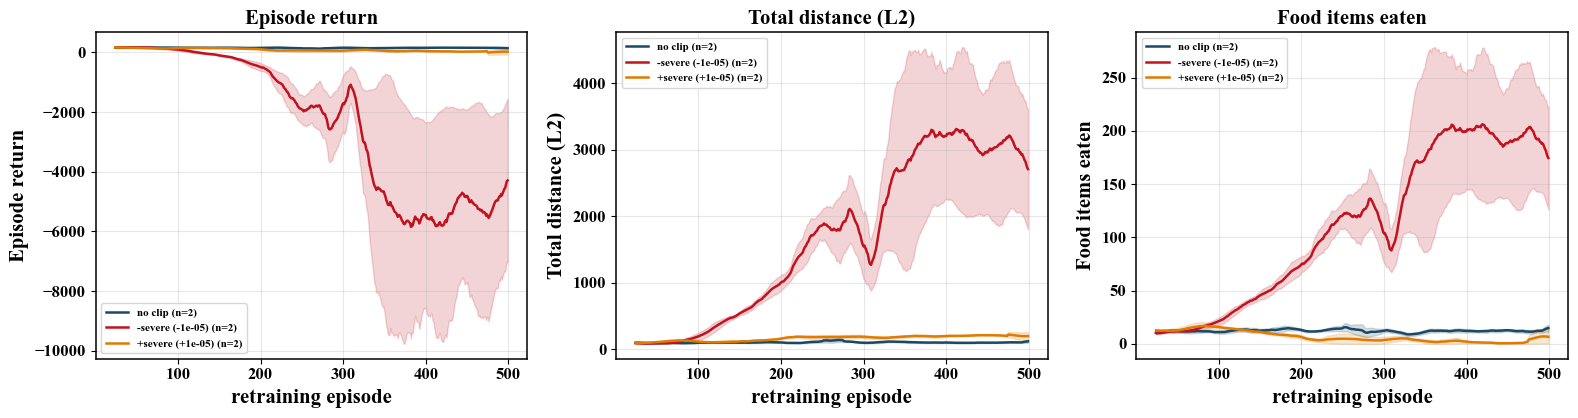

In [16]:
# ── Fig 5.1 — training curves (return / distance / consumption), 3 conditions overlaid ──
TM   = [('reward', 'Episode return'), ('distance', 'Total distance (L2)'), ('consumption', 'Food items eaten')]
ROLL = 25
def _rmean(x, w):
    x = np.asarray(x, float)
    return x if len(x) < w else np.convolve(x, np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for lbl in COND_ORDER:
    logs = RES[lbl].get('train', {})
    if not logs:
        continue
    for ax, (k, yl) in zip(axes, TM):
        arrs = [np.asarray(l[k], float) for l in logs.values() if k in l]
        if not arrs:
            continue
        Tm = min(map(len, arrs)); M = np.stack([a[:Tm] for a in arrs])
        mu = M.mean(0); se = M.std(0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros(Tm)
        mr, sr = _rmean(mu, ROLL), _rmean(se, ROLL); x = np.arange(len(mu))[len(mu) - len(mr):]
        ax.plot(x, mr, lw=1.8, color=CLR[lbl], label=f'{lbl} (n={M.shape[0]})')
        ax.fill_between(x, mr - sr, mr + sr, color=CLR[lbl], alpha=0.18)
for ax, (k, yl) in zip(axes, TM):
    ax.set_title(yl); ax.set_xlabel('retraining episode'); ax.set_ylabel(yl)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); save_fig(fig, 'fig5_td_clip', 'fig5_1_training_curves')
plt.show()

### Fig 5.2 — Episode-wise inference metrics (per condition)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig5_td_clip/fig5_2_episodewise_no_clip.[png|pdf|svg|eps]


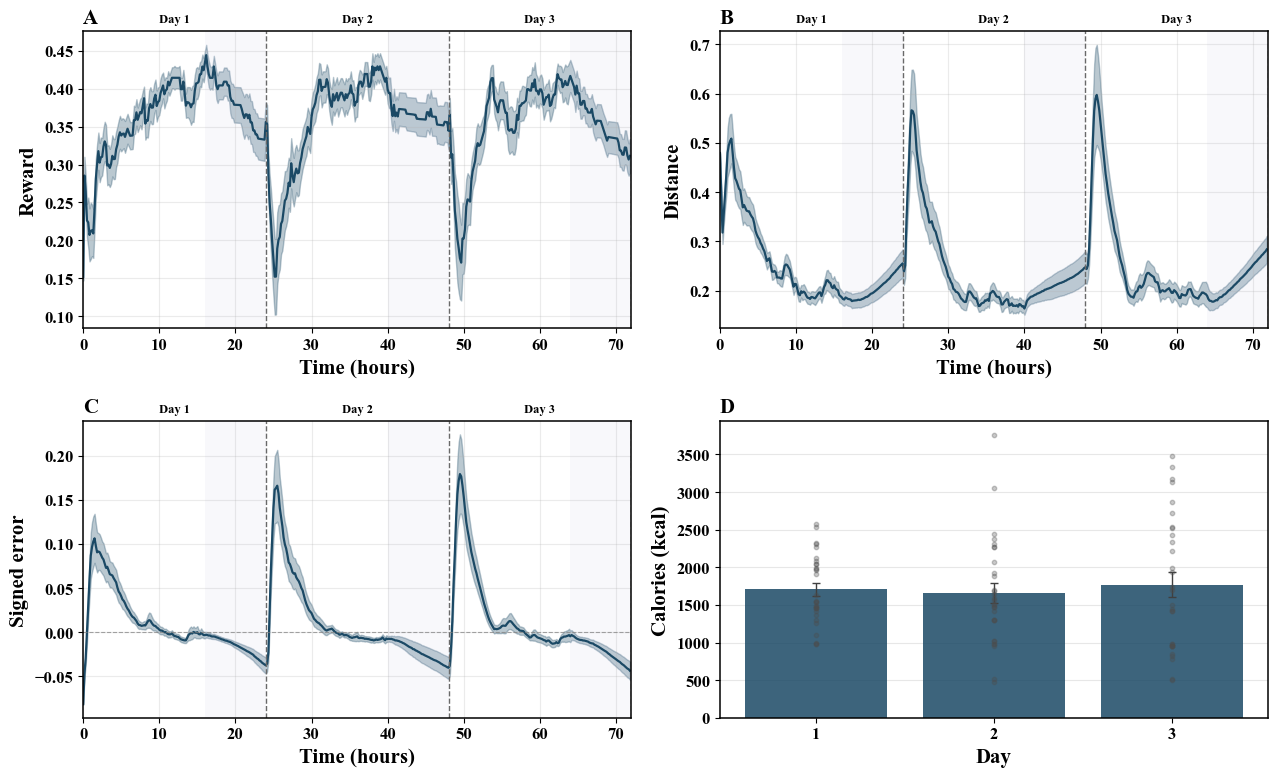

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig5_td_clip/fig5_2_episodewise_negsevere_neg1eneg05.[png|pdf|svg|eps]


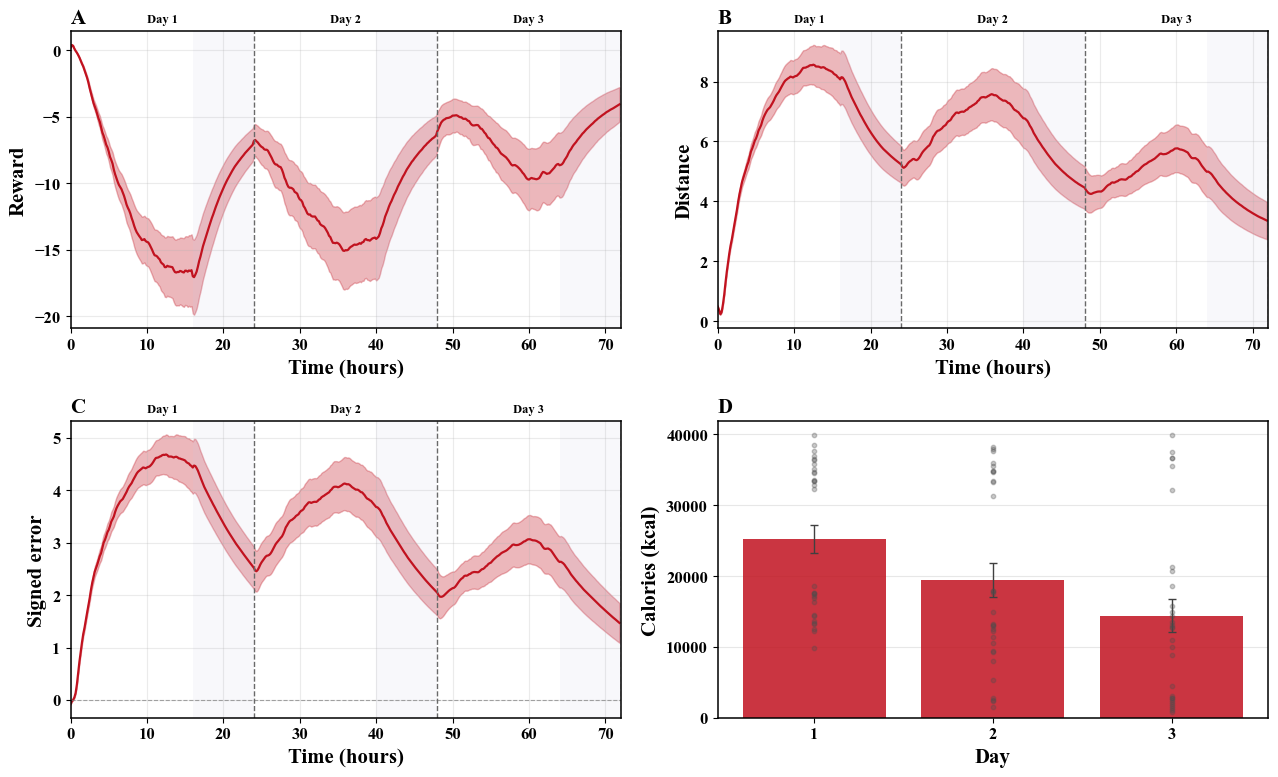

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig5_td_clip/fig5_2_episodewise_possevere_pos1eneg05.[png|pdf|svg|eps]


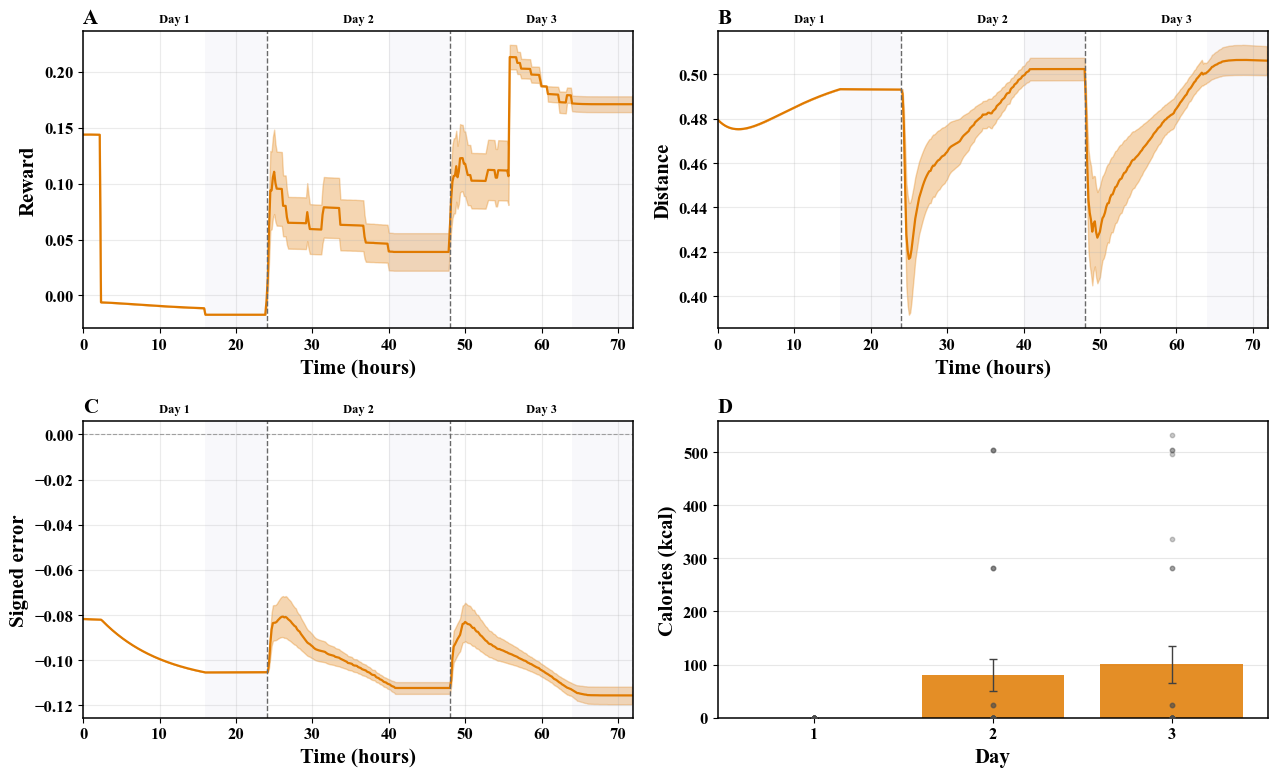

In [17]:
# ── Fig 5.2 — episode-wise reward/distance/signed-error (mean±SE) + calories/day, per condition ──
def _shade_days(ax, wins, sph, nd, cyc):
    for ws, we in wins: ax.axvspan(ws / sph, we / sph, alpha=0.12, color='#c9c9e6', lw=0)
    for d in range(1, nd + 1): ax.axvline(d * cyc / sph, color='dimgray', lw=1.0, ls='--')
def _msem(M):
    mu = M.mean(0); se = M.std(0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros(M.shape[1])
    return mu, se

for lbl in COND_ORDER:
    I = RES[lbl].get('infer')
    if I is None:
        continue
    T = I['T']; cyc = I['cycle_length']; sph = cyc / 24.0; hours = np.arange(T) / sph
    wins = _sleepwins(np.asarray(I['awake0']).astype(bool)); nd = int(np.ceil(T / cyc)); col = CLR[lbl]
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for ax, M, yl, tag in [(axes[0, 0], I['reward_steps'], 'Reward', 'A'),
                           (axes[0, 1], I['dist_steps'], 'Distance', 'B'),
                           (axes[1, 0], I['signed_steps'], 'Signed error', 'C')]:
        mu, se = _msem(np.asarray(M)[:, :T])
        ax.plot(hours, mu, color=col, lw=1.6); ax.fill_between(hours, mu - se, mu + se, color=col, alpha=0.30)
        if yl == 'Signed error': ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.7)
        _shade_days(ax, wins, sph, nd, cyc)
        for d in range(nd):
            ax.text((d + 0.5) * cyc / sph, 1.02, f'Day {d+1}', transform=ax.get_xaxis_transform(),
                    ha='center', va='bottom', fontsize=9)
        ax.set_ylabel(yl); ax.set_xlabel('Time (hours)'); ax.set_xlim(0, T / sph)
        ax.set_title(tag, loc='left', fontweight='bold'); ax.grid(alpha=0.25)
    ax = axes[1, 1]; cm = np.asarray(I['cal_per_day']); xd = np.arange(1, cm.shape[1] + 1)
    cnt = np.sum(~np.isnan(cm), 0); dmean = np.nanmean(cm, 0)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore'); dstd = np.nanstd(cm, 0, ddof=1)
    dsem = np.where(cnt > 1, dstd / np.sqrt(np.maximum(cnt, 1)), 0.0)
    ax.bar(xd, dmean, yerr=dsem, capsize=3, color=col, alpha=0.85, error_kw=dict(lw=1.0, ecolor='0.25'))
    for s in range(cm.shape[0]): ax.scatter(xd, cm[s], s=10, color='0.3', alpha=0.3, zorder=3)
    ax.set_xticks(xd); ax.set_xlabel('Day'); ax.set_ylabel('Calories (kcal)')
    ax.set_title('D', loc='left', fontweight='bold'); ax.grid(alpha=0.3, axis='y'); ax.set_axisbelow(True)
    fig.tight_layout()
    slug = lbl.replace(' ', '_').replace('(', '').replace(')', '').replace('+', 'pos').replace('-', 'neg')
    save_fig(fig, 'fig5_td_clip', f'fig5_2_episodewise_{slug}'); plt.show()

### Fig 5.3 — 3D + nutrient-space trajectories (baseline / +clip / -clip)

/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_5220/3182416052.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); save_fig(fig, 'fig5_td_clip', 'fig5_3_trajectories')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig5_td_clip/fig5_3_trajectories.[png|pdf|svg|eps]


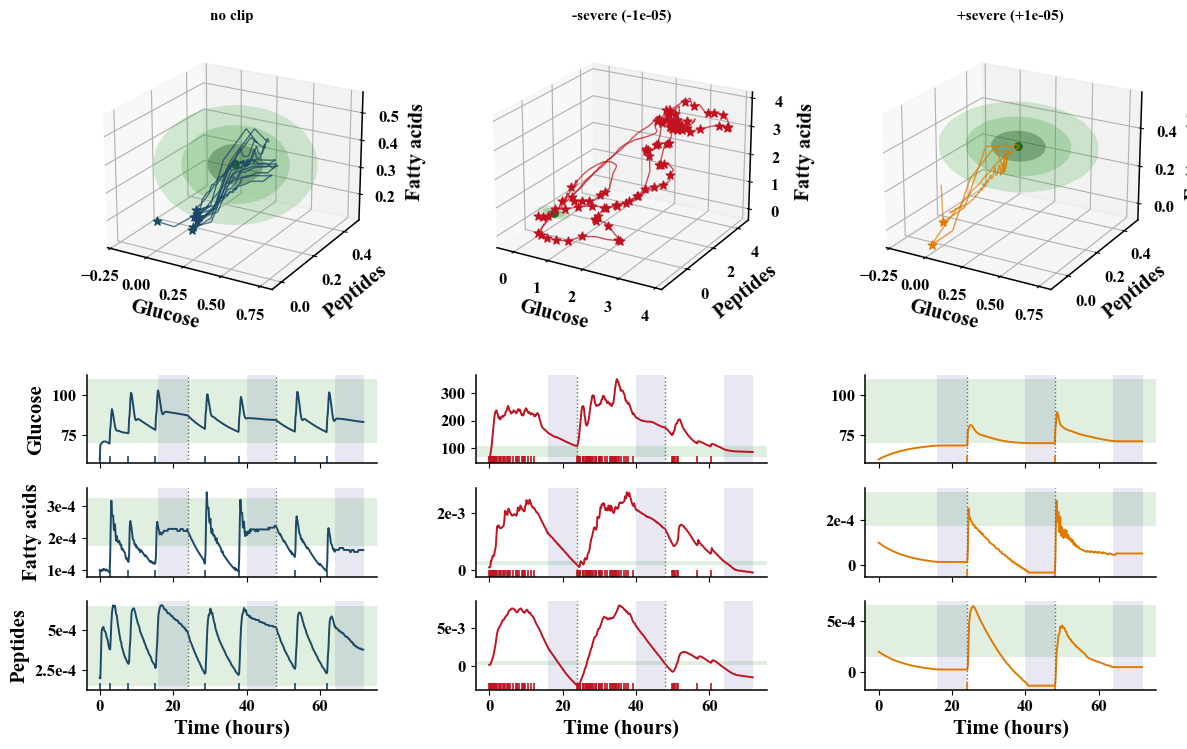

In [18]:
# ── Fig 5.3 — 3D nutrient-space trajectory (A-C) + raw nutrient rows (D-F) per condition ──
# Needs rep_eat_steps + nutrient minmax (added to td_clip_retrain capture; re-run that notebook).
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import matplotlib.colors as mcolors
from matplotlib.transforms import blended_transform_factory
from matplotlib.ticker import FuncFormatter

AXL = ['Glucose', 'Peptides', 'Fatty acids']          # 3D axis order = names order
NR  = ['glucose', 'fatty_acids', 'peptides']          # raw-row order (Fig-1 convention)
NN  = {'glucose': 'Glucose', 'fatty_acids': 'Fatty acids', 'peptides': 'Peptides'}
SCI = {'fatty_acids', 'peptides'}
def _sci(v, _):
    if v == 0: return '0'
    e = int(np.floor(np.log10(abs(v)))); return f'{v/10**e:g}e{e}'

conds   = [l for l in COND_ORDER if 'infer' in RES.get(l, {})]
missing = [l for l in conds if 'rep_eat_steps' not in RES[l]['infer'] or 'minmax' not in RES[l]['infer']]
if missing:
    print('Fig 5.3 needs eat_steps + minmax — re-run td_clip_retrain.ipynb. Missing for:', missing)
else:
    nc = len(conds)
    fig = plt.figure(figsize=(4.6 * nc, 9))
    gs  = fig.add_gridspec(4, nc, height_ratios=[4, 1, 1, 1], hspace=0.16, wspace=0.34)
    for k, lbl in enumerate(conds):
        I = RES[lbl]['infer']; names = I['names']; col = mcolors.to_rgb(CLR[lbl])
        traj = np.asarray(I['rep_traj']); eat = np.asarray(I['rep_eat_steps'])
        awake = np.asarray(I['rep_awake']).astype(bool)
        low, high, tgt = np.asarray(I['low']), np.asarray(I['high']), np.asarray(I['tgt']); mm = I['minmax']
        cyc = I['cycle_length']; sph = cyc / 24.0; T = traj.shape[0]; hours = np.arange(T) / sph

        ax = fig.add_subplot(gs[0, k], projection='3d', computed_zorder=False)
        c = (low + high) / 2.0; a0 = (high - low) / 2.0 * 1.75; u, v = np.mgrid[0:2*np.pi:24j, 0:np.pi:16j]
        for sc, cl, al in [(1.0, '#32A432', 0.10), (0.66, '#3FA23F', 0.13), (0.34, '#083C08', 0.16)]:
            a = a0 * sc
            ax.plot_surface(c[0]+a[0]*np.cos(u)*np.sin(v), c[1]+a[1]*np.sin(u)*np.sin(v),
                            c[2]+a[2]*np.cos(v), color=cl, alpha=al, linewidth=0, shade=False)
        ax.scatter([tgt[0]], [tgt[1]], [tgt[2]], color='#1B6B1B', s=28)
        pts = traj.reshape(-1, 1, 3); segs = np.concatenate([pts[:-1], pts[1:]], 1)
        sty = ['solid' if awake[i] else 'dashed' for i in range(len(segs))]
        ax.add_collection3d(Line3DCollection(segs, colors=col, linestyles=sty, linewidths=1.0, alpha=0.75))
        if len(eat): ax.scatter(traj[eat, 0], traj[eat, 1], traj[eat, 2], marker='*', s=40, color=col, depthshade=False)
        ax.set_xlabel(AXL[0]); ax.set_ylabel(AXL[1]); ax.set_zlabel(AXL[2])
        ax.view_init(elev=22, azim=-60); ax.set_title(lbl, fontsize=11)

        for ri, nm in enumerate(NR):
            if nm not in names: continue
            ax = fig.add_subplot(gs[1+ri, k])                 # independent y-axis per panel
            i = names.index(nm); vmin, vmax = mm[nm]; rng = vmax - vmin
            ax.axhspan(low[i]*rng+vmin, high[i]*rng+vmin, color='green', alpha=0.12, lw=0)
            for ws, we in _sleepwins(awake): ax.axvspan(ws/sph, we/sph, color='navy', alpha=0.09, lw=0)
            ax.plot(hours, traj[:, i]*rng+vmin, color=col, lw=1.4)
            for x in range(24, int(T/sph), 24): ax.axvline(x, color='dimgray', lw=1.0, ls=':')
            tr = blended_transform_factory(ax.transData, ax.transAxes)
            if len(eat): ax.vlines(eat/sph, 0, 0.08, transform=tr, color=col, lw=1.2)
            ax.spines[['top', 'right']].set_visible(False)
            if nm in SCI: ax.yaxis.set_major_formatter(FuncFormatter(_sci))   # each panel keeps its own scale
            if ri < 2: plt.setp(ax.get_xticklabels(), visible=False)
            else: ax.set_xlabel('Time (hours)')
            if k == 0: ax.set_ylabel(NN[nm])
    fig.tight_layout(); save_fig(fig, 'fig5_td_clip', 'fig5_3_trajectories')
    plt.show()

### Fig 5.4 & 5.5 — Clip-magnitude sweep vs baseline

Positive del-lims available : ['+1e-06', '+2e-06', '+3e-06', '+5e-06', '+1e-05', '+2e-05', '+3e-05', '+5e-05', '+0.0001', '+0.0002', '+0.0003', '+0.0005', '+0.001', '+0.002', '+0.003', '+0.005', '+0.01', '+0.03', '+0.05']
Negative del-lims available : ['-1e-06', '-2e-06', '-3e-06', '-5e-06', '-1e-05', '-2e-05', '-3e-05', '-5e-05', '-0.0001', '-0.0002', '-0.0003', '-0.0005', '-0.001', '-0.002', '-0.003', '-0.005']


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig5_td_clip/fig5_4_pos_sweep.[png|pdf|svg|eps]


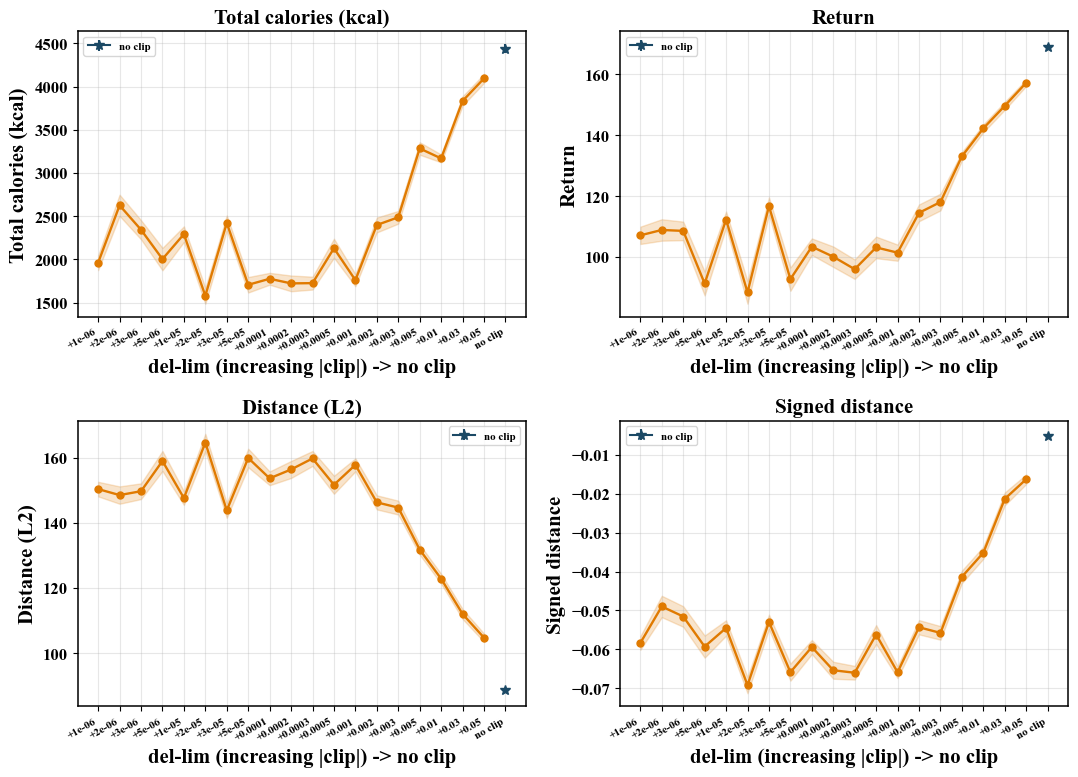

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig5_td_clip/fig5_5_neg_sweep.[png|pdf|svg|eps]


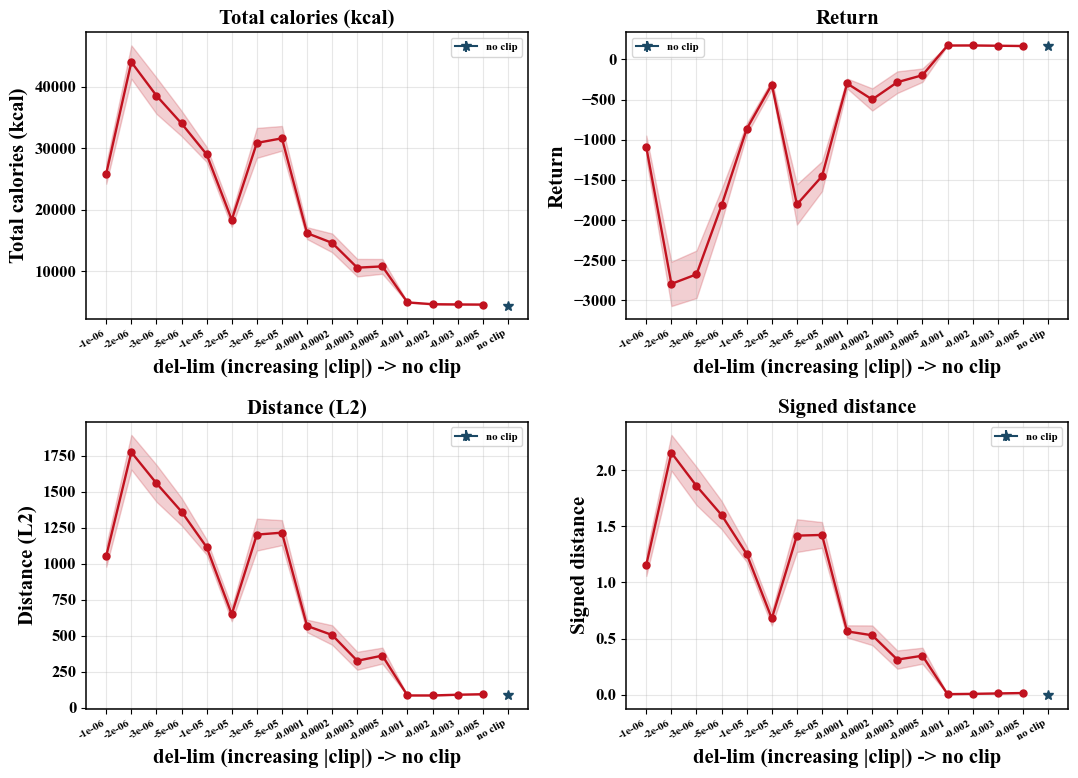

In [19]:
# ── Fig 5.4 / 5.5 — metric vs del-lim, with no-clip as the right-most point (2x2) ──
# All available del-lims are printed below; copy the label strings you want into
# SELECT_POS / SELECT_NEG to plot only those (None or [] = plot all).
_pos_all = list(sweep['severity_pos'][~sweep['severity_pos']['is_noclip']]
                .sort_values('severity')['label'])
_neg_all = list(sweep['severity_neg'][~sweep['severity_neg']['is_noclip']]
                .sort_values('severity')['label'])
print('Positive del-lims available :', _pos_all)
print('Negative del-lims available :', _neg_all)

# ▼▼▼ CHOOSE WHICH TO PLOT (None/[] = all). Use the labels printed above. ▼▼▼
SELECT_POS = None     # e.g. ['+1e-06', '+1e-05', '+0.0001', '+0.001']
SELECT_NEG = None     # e.g. ['-1e-06', '-1e-05', '-0.0001', '-0.001']
# ▲▲▲──────────────────────────────────────────────────────────────────▲▲▲

M4 = [('calories', 'Total calories (kcal)'), ('return', 'Return'),
      ('distance', 'Distance (L2)'), ('signed_dist', 'Signed distance')]

def _sweep_grid(fr, title, color, fname, select=None):
    base = fr[fr['is_noclip']]
    pts  = fr[~fr['is_noclip']].sort_values('severity')
    if select:
        missing = sorted(set(select) - set(pts['label']))
        if missing:
            print(f'  [warn] {fname}: labels not found, ignored -> {missing}')
        pts = pts[pts['label'].isin(select)]
    if pts.empty:
        print(f'  [skip] {fname}: no del-lims selected.'); return
    xc = np.arange(len(pts))                      # clipped del-lim positions
    xb = len(pts)                                 # no-clip position (right-most)
    labels = pts['label'].tolist() + (['no clip'] if len(base) else [])
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, (k, lab) in zip(axes.ravel(), M4):
        ax.plot(xc, pts[f'{k}_mean'], marker='o', ms = 5, color=color, lw=1.7)
        ax.fill_between(xc, pts[f'{k}_mean'] - pts[f'{k}_sem'], pts[f'{k}_mean'] + pts[f'{k}_sem'],
                        color=color, alpha=0.2)
        if len(base):                             # no-clip as a distinct right-most point
            ax.errorbar([xb], [base[f'{k}_mean'].iloc[0]], yerr=[base[f'{k}_sem'].iloc[0]],
                        marker='*', ms=7, color=C_NORMAL, capsize=0, lw=1.5, label='no clip')
            ax.legend(fontsize=8)
        ax.set_xticks(list(xc) + ([xb] if len(base) else []))
        ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
        ax.set_xlabel('del-lim (increasing |clip|) -> no clip'); ax.set_ylabel(lab)
        ax.set_title(lab); ax.grid(alpha=0.3)
    fig.tight_layout()
    save_fig(fig, 'fig5_td_clip', fname); plt.show()

_sweep_grid(sweep['severity_pos'], 'Fig 5.4 — Positive clip sweep vs baseline',
            C_UNDER, 'fig5_4_pos_sweep', select=SELECT_POS)
_sweep_grid(sweep['severity_neg'], 'Fig 5.5 — Negative clip sweep vs baseline',
            C_OVER, 'fig5_5_neg_sweep', select=SELECT_NEG)